# Determining Vacation Purchase

## Objective

Build a model that can predict whether or not potential customers will purchase a new vacation package.

## Data Dictionary
- CustomerID: Unique customer ID
- ProdTaken: Whether the customer has purchased a package or not (0: No, 1: Yes)
- Age: Age of customer
- TypeofContact: How customer was contacted (Company Invited or Self Inquiry)
- CityTier: City tier depends on the development of a city, population, facilities, and living standards. The categories are ordered i.e. Tier 1 > Tier 2 > Tier 3
- DurationOfPitch: Duration of the pitch by a salesperson to the customer
- Occupation: Occupation of customer
- Gender: Gender of customer
- NumberOfPersonVisiting: Total number of people planning to take the trip with the customer
- NumberOfFollowups: Total number of follow-ups has been done by the salesperson after the sales pitch
- ProductPitched: Product pitched by the salesperson
- PreferredPropertyStar: Preferred hotel property rating by customer
- MaritalStatus: Marital status of customer
- NumberOfTrips: Average number of trips in a year by customer
- Passport: The customer has a passport or not (0: No, 1: Yes)
- PitchSatisfactionScore: Sales pitch satisfaction score
- OwnCar: Whether the customers own a car or not (0: No, 1: Yes)
- NumberOfChildrenVisiting: Total number of children with age less than 5 planning to take the trip with the customer
- Designation: Designation of the customer in the current organization
- MonthlyIncome: Gross monthly income of the customer

### Load Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data

In [2]:
df = pd.read_csv("vacation_package.csv")

## Data Overview

In [3]:
df.sample(20)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
1757,201757,0,38.0,Self Enquiry,1,29.0,Salaried,Male,2,3.0,Deluxe,3.0,Married,1.0,0,3,0,1.0,Manager,20745.0
54,200054,0,NaN,Self Enquiry,3,29.0,Small Business,Female,2,4.0,Deluxe,3.0,Divorced,1.0,1,2,1,0.0,Manager,NaN
3955,203955,0,28.0,Self Enquiry,1,9.0,Salaried,Female,3,4.0,Basic,5.0,Married,3.0,0,3,1,2.0,Executive,21019.0
4578,204578,0,37.0,Self Enquiry,1,21.0,Salaried,Male,4,4.0,Deluxe,3.0,Married,2.0,1,5,1,1.0,Manager,25264.0
1496,201496,1,NaN,Company Invited,1,22.0,Salaried,Female,3,5.0,Basic,5.0,Single,2.0,1,4,0,0.0,Executive,NaN
2197,202197,0,18.0,Company Invited,1,11.0,Salaried,Male,3,3.0,Basic,3.0,Single,2.0,0,1,0,1.0,Executive,16051.0
506,200506,0,37.0,Self Enquiry,1,9.0,Salaried,Male,2,3.0,Standard,3.0,Divorced,2.0,0,2,1,0.0,Senior Manager,24434.0
3294,203294,0,33.0,Company Invited,3,9.0,Salaried,Female,4,4.0,Basic,5.0,Married,3.0,0,3,0,2.0,Executive,21505.0
2578,202578,0,27.0,Self Enquiry,2,32.0,Salaried,Female,4,4.0,Basic,3.0,Divorced,3.0,0,4,1,1.0,Executive,21620.0
2140,202140,0,27.0,Self Enquiry,1,10.0,Salaried,Female,3,3.0,Basic,3.0,Single,2.0,0,1,0,0.0,Executive,17318.0


In [4]:
df.shape

(4888, 20)

- 4888 rows and 20 columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

<b>Numeric features:</b>
<ul>
    <li>Age</li>
    <li>DurationOfPitch</li>
    <li>NumberOfPersonVisiting</li>
    <li>NumberOfFollowups</li>
    <li>NumberOfTrips</li>
    <li>NumberOfChildrenVisiting</li>
    <li>MonthlyIncome</li>
    <li>PreferredPropertyStar</li>
</ul>
<b>Categorical Features:</b> 
<ul>
    <li>CustomerID</li>
    <li>ProdTaken</li>
    <li>TypeofContact</li>
    <li>CityTier</li>
    <li>Occupation</li>
    <li>Gender</li>
    <li>ProductPitched</li>
    <li>PitchSatisfactionScore</li>
    <li>MaritalStatus</li>
    <li>Passport</li>
    <li>OwnCar</li>
    <li>Designation</li>
</ul>

In [6]:
# Checking for duplicated values
df.duplicated().sum()

0

In [7]:
# Number of missing values in each row
df.isna().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4888.0,202443.500000,1411.188388,200000.0,201221.75,202443.5,203665.25,204887.0
ProdTaken,4888.0,0.188216,0.390925,0.0,0.00,0.0,0.00,1.0
Age,4662.0,37.622265,9.316387,18.0,31.00,36.0,44.00,61.0
CityTier,4888.0,1.654255,0.916583,1.0,1.00,1.0,3.00,3.0
DurationOfPitch,4637.0,15.490835,8.519643,5.0,9.00,13.0,20.00,127.0
NumberOfPersonVisiting,4888.0,2.905074,0.724891,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4843.0,3.708445,1.002509,1.0,3.00,4.0,4.00,6.0
PreferredPropertyStar,4862.0,3.581037,0.798009,3.0,3.00,3.0,4.00,5.0
NumberOfTrips,4748.0,3.236521,1.849019,1.0,2.00,3.0,4.00,22.0
Passport,4888.0,0.290917,0.454232,0.0,0.00,0.0,1.00,1.0


In [9]:
df.nunique()

CustomerID                  4888
ProdTaken                      2
Age                           44
TypeofContact                  2
CityTier                       3
DurationOfPitch               34
Occupation                     4
Gender                         3
NumberOfPersonVisiting         5
NumberOfFollowups              6
ProductPitched                 5
PreferredPropertyStar          3
MaritalStatus                  4
NumberOfTrips                 12
Passport                       2
PitchSatisfactionScore         5
OwnCar                         2
NumberOfChildrenVisiting       4
Designation                    5
MonthlyIncome               2475
dtype: int64

In [10]:
# Looking at our target variable
df['ProdTaken'].value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

<b>Observations</b>
<ul>
    <li>Age ranges from 18-61</li>
    <li>Monthly income ranges between 1000 and 98678 with the 75 percentile being 25571</li>
    <li>Children visiting ranges between 0 and 3</li>
    <li>Number of people visiting between 1 and 5</li>
    <li>Number of follow ups between 1 and 6</li>
    <li>Number of trips between 1 and 22 with 75 percentile being 4</li>
    <li>Missing values for age, duration of pitch, number of follow ups, preffered property star, number of trips, children visiting, and monthly income</li>
    <li>Outliers in duration of pitch, number of trips, and monthly income</li>
    <li>Majority of people did not take the package</li>
</ul>

## Data preprocessing

Firstly, we are removing CustomerID, as it has a unique value for each entry

In [11]:
df = df.drop(['CustomerID'], axis=1)

In [12]:
df.sample(5)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
3183,0,28.0,Self Enquiry,1,9.0,Salaried,Female,3,4.0,Deluxe,3.0,Divorced,2.0,0,5,0,2.0,Manager,22905.0
4306,0,55.0,Self Enquiry,1,12.0,Small Business,Male,3,4.0,King,5.0,Married,NaN,0,4,1,1.0,VP,38084.0
4670,0,33.0,Company Invited,1,36.0,Small Business,Female,4,4.0,Basic,3.0,Unmarried,2.0,0,3,1,3.0,Executive,22703.0
2879,1,34.0,Self Enquiry,1,22.0,Small Business,Male,3,4.0,Standard,3.0,Divorced,2.0,1,5,0,1.0,Senior Manager,32288.0
1620,0,40.0,Company Invited,1,32.0,Small Business,Female,2,3.0,Deluxe,4.0,Married,2.0,0,1,0,1.0,Manager,20605.0


### Missing Values

#### Age

In [13]:
df['Age'].isna().sum()

226

In [14]:
df.Age.describe().T

count    4662.000000
mean       37.622265
std         9.316387
min        18.000000
25%        31.000000
50%        36.000000
75%        44.000000
max        61.000000
Name: Age, dtype: float64

In [15]:
df[df['Age'].isnull()]

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
4,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
11,0,NaN,Self Enquiry,1,21.0,Salaried,Female,2,4.0,Deluxe,3.0,Single,1.0,1,3,0,0.0,Manager,NaN
19,0,NaN,Self Enquiry,1,8.0,Salaried,Male,2,3.0,Basic,3.0,Single,6.0,1,4,0,1.0,Executive,NaN
20,0,NaN,Company Invited,1,17.0,Salaried,Female,3,2.0,Deluxe,3.0,Married,1.0,0,3,1,2.0,Manager,NaN
21,1,NaN,Self Enquiry,3,15.0,Salaried,Male,2,4.0,Deluxe,5.0,Single,1.0,0,2,0,0.0,Manager,18407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2410,1,NaN,Self Enquiry,1,30.0,Small Business,Male,2,3.0,Basic,4.0,Married,2.0,1,1,0,0.0,Executive,NaN
2413,1,NaN,Self Enquiry,3,21.0,Small Business,Male,2,5.0,Deluxe,3.0,Married,7.0,1,1,0,1.0,Manager,18423.0
2427,1,NaN,Self Enquiry,3,22.0,Small Business,Male,3,3.0,Standard,3.0,Married,3.0,0,5,0,1.0,Senior Manager,18544.0
2430,1,NaN,Self Enquiry,1,14.0,Small Business,Female,3,3.0,Basic,5.0,Married,2.0,1,3,0,2.0,Executive,NaN


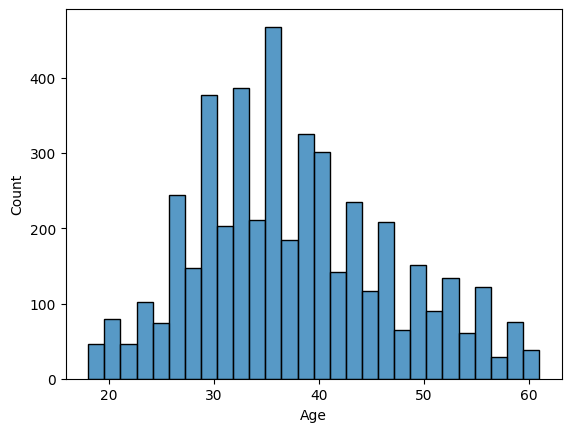

In [16]:
sns.histplot(df['Age']);

Since the column's distribution is slightly skewed right, its missing values will be replaced with the median of 36.

In [17]:
df.loc[df.Age.isnull(), 'Age'] = 36

In [18]:
df['Age'].isna().sum()

0

In [19]:
df.Age.describe().T

count    4888.000000
mean       37.547259
std         9.104795
min        18.000000
25%        31.000000
50%        36.000000
75%        43.000000
max        61.000000
Name: Age, dtype: float64

Statistics for the Age column did not change much after making this change.

In [20]:
df['TypeofContact'].isna().sum()

25

#### Type of Contact

In [21]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [22]:
df[df['TypeofContact'].isnull()]

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
224,0,31.0,NaN,1,NaN,Small Business,Male,2,5.0,Deluxe,3.0,Divorced,1.0,0,3,1,0.0,Manager,NaN
571,0,26.0,NaN,1,NaN,Salaried,Female,3,5.0,Basic,3.0,Married,4.0,0,4,1,2.0,Executive,NaN
572,0,29.0,NaN,1,NaN,Small Business,Female,3,3.0,Deluxe,3.0,Divorced,5.0,0,2,1,0.0,Manager,NaN
576,0,27.0,NaN,3,NaN,Small Business,Male,2,3.0,Deluxe,3.0,Divorced,1.0,0,3,0,1.0,Manager,NaN
579,0,34.0,NaN,1,NaN,Small Business,Female,2,4.0,Basic,5.0,Single,2.0,0,2,1,1.0,Executive,NaN
598,1,28.0,NaN,1,NaN,Small Business,Male,2,3.0,Basic,3.0,Single,7.0,0,3,0,0.0,Executive,NaN
622,0,32.0,NaN,3,NaN,Salaried,Male,3,3.0,Deluxe,3.0,Married,3.0,0,2,0,0.0,Manager,NaN
724,0,24.0,NaN,1,NaN,Small Business,Female,2,4.0,Deluxe,3.0,Married,2.0,0,3,1,1.0,Manager,NaN
843,0,26.0,NaN,1,NaN,Small Business,Male,2,1.0,Basic,3.0,Divorced,2.0,0,5,1,1.0,Executive,NaN
1021,1,25.0,NaN,3,NaN,Salaried,Male,3,4.0,Basic,5.0,Divorced,4.0,0,1,1,0.0,Executive,NaN


As shown above, all rows that contain a missing value in TypeOfContact also appear to having missing values in DurationOfPitch and MonthlyIncome. Because of this, any rows with missing values in TypeOfContact will be dropped from the df, due to the absence of three potentially important variables.

In [23]:
df.dropna(subset=['TypeofContact'], inplace=True)

In [24]:
df['TypeofContact'].isna().sum()

0

In [25]:
df['DurationOfPitch'].isna().sum()

226

In [26]:
df['MonthlyIncome'].isna().sum()

208

Since these two columns are numerical, their values cannot simply be replaced with 'Unknown', or something similar. Instead, we will need to replace the missing values with either a median or a mean. First, we need to check their distributions.

#### Duration of Pitch

In [27]:
df['DurationOfPitch'].describe()

count    4637.000000
mean       15.490835
std         8.519643
min         5.000000
25%         9.000000
50%        13.000000
75%        20.000000
max       127.000000
Name: DurationOfPitch, dtype: float64

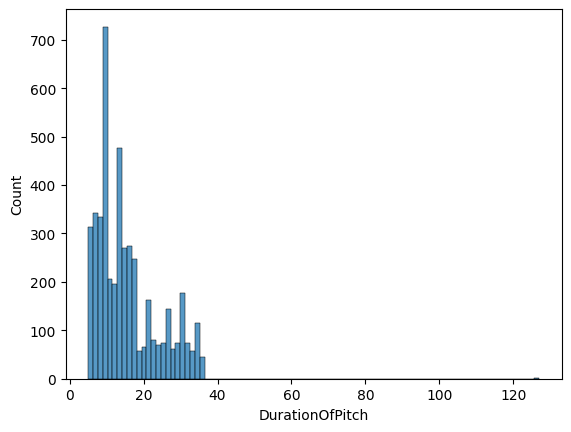

In [28]:
sns.histplot(df['DurationOfPitch']);

Since this column's distribution is heavily right-skewed, its missing values will be replaced with the median of 13.

In [29]:
df.loc[df.DurationOfPitch.isnull(), 'DurationOfPitch'] = 13

In [30]:
df['DurationOfPitch'].isnull().sum()

0

#### Monthly Income

In [31]:
df['MonthlyIncome'].describe()

count     4655.000000
mean     23619.853491
std       5380.698361
min       1000.000000
25%      20346.000000
50%      22347.000000
75%      25571.000000
max      98678.000000
Name: MonthlyIncome, dtype: float64

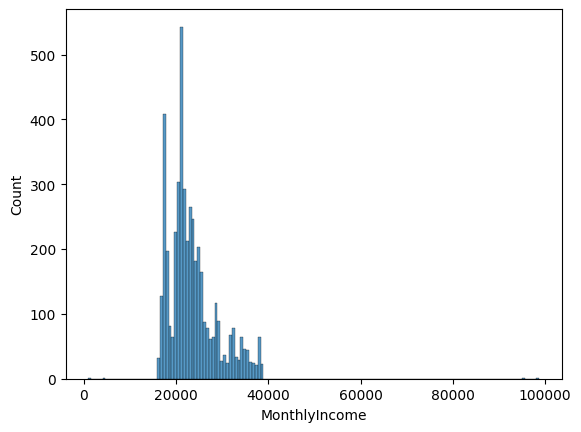

In [32]:
sns.histplot(df['MonthlyIncome']);

Since this column's distribution is also heavily right-skewed, its missing values will be replaced with the median of 22,347.

In [33]:
df.loc[df['MonthlyIncome'].isnull(), 'MonthlyIncome'] = 22347

In [34]:
df['MonthlyIncome'].isnull().sum()

0

Next, we will check the other columns

In [35]:
df.isnull().sum()

ProdTaken                     0
Age                           0
TypeofContact                 0
CityTier                      0
DurationOfPitch               0
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome                 0
dtype: int64

#### Number of Followups

In [36]:
df['NumberOfFollowups'].describe()

count    4818.000000
mean        3.710668
std         1.000796
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         6.000000
Name: NumberOfFollowups, dtype: float64

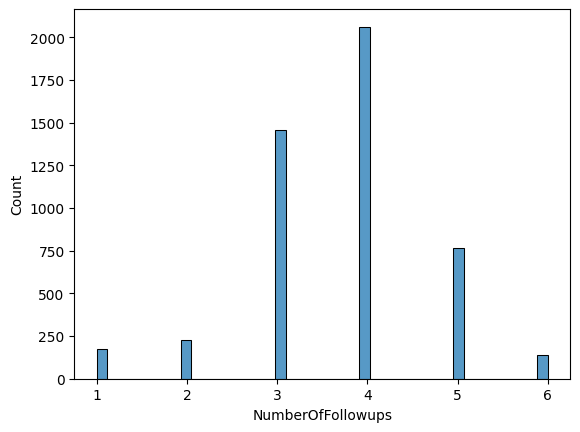

In [37]:
sns.histplot(df['NumberOfFollowups']);

Since this column's distribution is slightly skewed, its missing values will be replaced with the median of 4.

In [38]:
df.loc[df['NumberOfFollowups'].isnull(), 'NumberOfFollowups'] = 4

In [39]:
df['NumberOfFollowups'].isnull().sum()

0

#### Number of Trips

In [40]:
df['NumberOfTrips'].describe()

count    4723.000000
mean        3.238196
std         1.848969
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        22.000000
Name: NumberOfTrips, dtype: float64

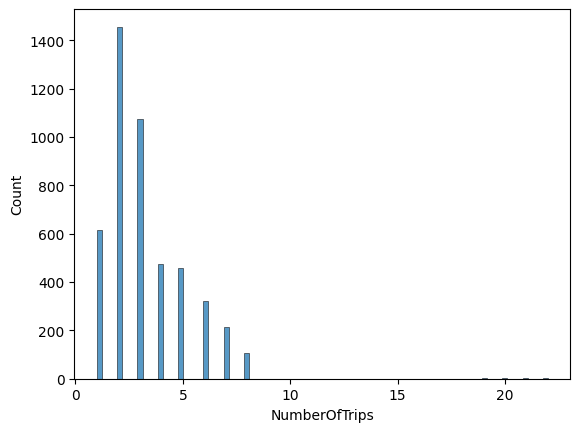

In [41]:
sns.histplot(df['NumberOfTrips']);

Since this column's distribution is heavily skewed right, its missing values will be replaced with the median of 3.

In [42]:
df.loc[df['NumberOfTrips'].isnull(), 'NumberOfTrips'] = 3

In [43]:
df['NumberOfTrips'].isnull().sum()

0

#### Number of Children Visiting

In [44]:
df['NumberOfChildrenVisiting'].describe()

count    4797.000000
mean        1.190327
std         0.857828
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: NumberOfChildrenVisiting, dtype: float64

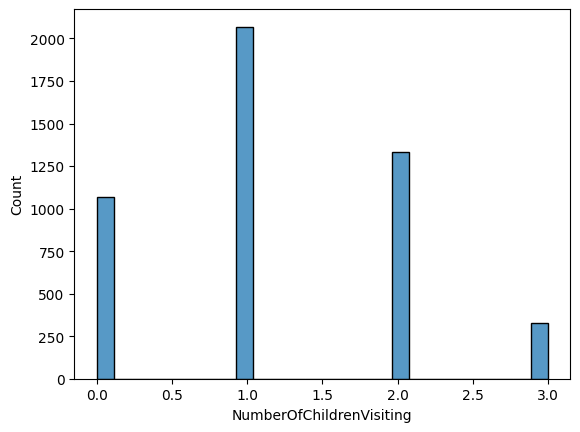

In [45]:
sns.histplot(df['NumberOfChildrenVisiting']);

Since the distribution for this column is slightly skewed right, its missing values will be replaced with the median of 1.

In [46]:
df.loc[df['NumberOfChildrenVisiting'].isnull(), 'NumberOfChildrenVisiting'] = 1

In [47]:
df['NumberOfChildrenVisiting'].isnull().sum()

0

#### Preferred Property Star

In [48]:
df['PreferredPropertyStar'].describe()

count    4837.000000
mean        3.581766
std         0.797913
min         3.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: PreferredPropertyStar, dtype: float64

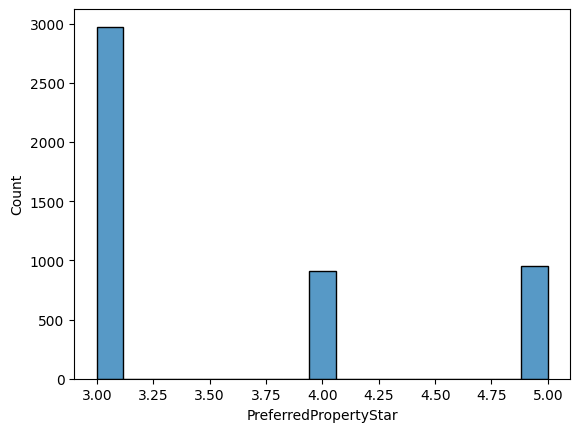

In [49]:
sns.histplot(df['PreferredPropertyStar']);

This column is strange, as it could be considered numeric or categorical. Thankfully, it doesn't matter because the missing values would be replaced with 3 anyways, as it is both the median and mode.

In [50]:
df.loc[df['PreferredPropertyStar'].isnull(), 'PreferredPropertyStar'] = 3

In [51]:
df['PreferredPropertyStar'].isnull().sum()

0

In [52]:
df.isnull().sum()

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

### Outliers

In [53]:
df[['Age','DurationOfPitch','NumberOfPersonVisiting','NumberOfFollowups','NumberOfTrips',
   'NumberOfChildrenVisiting','MonthlyIncome','PreferredPropertyStar']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4863.0,37.585647,9.104766,18.0,31.0,36.0,43.0,61.0
DurationOfPitch,4863.0,15.375077,8.335788,5.0,9.0,13.0,19.0,127.0
NumberOfPersonVisiting,4863.0,2.908081,0.724762,1.0,2.0,3.0,3.0,5.0
NumberOfFollowups,4863.0,3.713346,0.996539,1.0,3.0,4.0,4.0,6.0
NumberOfTrips,4863.0,3.231339,1.822589,1.0,2.0,3.0,4.0,22.0
NumberOfChildrenVisiting,4863.0,1.187744,0.852271,0.0,1.0,1.0,2.0,3.0
MonthlyIncome,4863.0,23565.411063,5270.642955,1000.0,20479.0,22347.0,25447.5,98678.0
PreferredPropertyStar,4863.0,3.578655,0.796907,3.0,3.0,3.0,4.0,5.0


As stated earlier, at a glance, it appears as though <b>DurationOfPitch</b>, <b>NumberOfTrips</b>, and <b>MonthlyIncome</b> all have outliers, so let's check those columns.

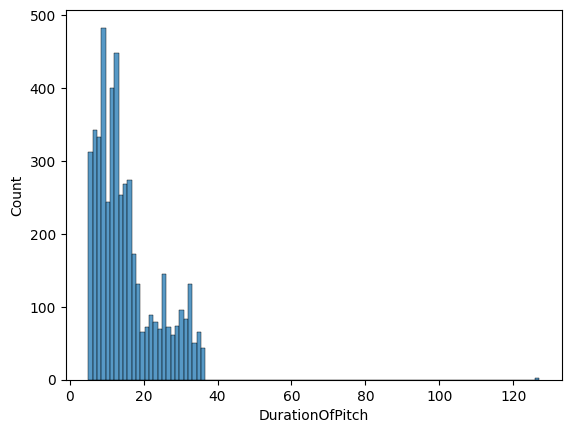

In [54]:
sns.histplot(df['DurationOfPitch']);

In [55]:
df[df['DurationOfPitch'] > 40]

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
1434,0,36.0,Company Invited,3,126.0,Salaried,Male,2,3.0,Basic,3.0,Married,3.0,0,1,1,1.0,Executive,18482.0
3878,0,53.0,Company Invited,3,127.0,Salaried,Male,3,4.0,Basic,3.0,Married,4.0,0,1,1,2.0,Executive,22160.0


These values are wildly beyond the upper fence for this column, so their values will be normalized with its median.

In [56]:
df.loc[df['DurationOfPitch'] > 40, ['DurationOfPitch']] = df['DurationOfPitch'].median()

In [57]:
# Verifying
df[df['DurationOfPitch'] > 40]

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome


In [58]:
df['NumberOfTrips'].describe()

count    4863.000000
mean        3.231339
std         1.822589
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        22.000000
Name: NumberOfTrips, dtype: float64

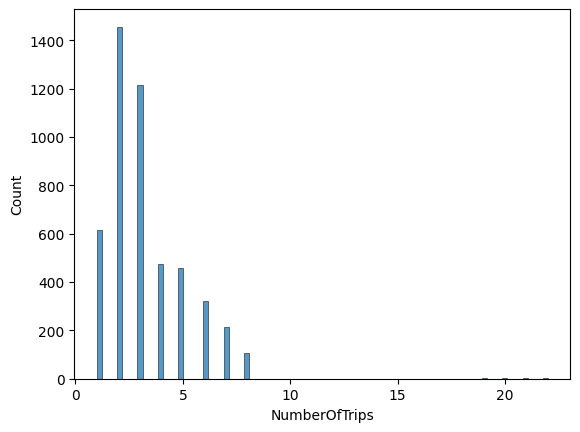

In [59]:
sns.histplot(df['NumberOfTrips']);

In [60]:
df[df['NumberOfTrips'] > 10]

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
385,1,30.0,Company Invited,1,10.0,Large Business,Male,2,3.0,Basic,3.0,Single,19.0,1,4,1,1.0,Executive,17285.0
816,0,39.0,Company Invited,1,15.0,Salaried,Male,3,3.0,Deluxe,4.0,Unmarried,21.0,0,2,1,0.0,Manager,21782.0
2829,1,31.0,Company Invited,1,11.0,Large Business,Male,3,4.0,Basic,3.0,Single,20.0,1,4,1,2.0,Executive,20963.0
3260,0,40.0,Company Invited,1,16.0,Salaried,Male,4,4.0,Deluxe,4.0,Unmarried,22.0,0,2,1,1.0,Manager,25460.0


At first thought, these values didn't seem entirely unbelievable, as these entries represent individuals whose trips are paid for by their company/employer, and they each have a high income. However, even accounting for these two variables, having the column's value be this high is too distant from the rest of the dataframe to leave them be. As such, they will be replaced with the column's median.

In [61]:
df.loc[df['NumberOfTrips'] > 10, ['NumberOfTrips']] = 3

In [62]:
df['MonthlyIncome'].describe()

count     4863.000000
mean     23565.411063
std       5270.642955
min       1000.000000
25%      20479.000000
50%      22347.000000
75%      25447.500000
max      98678.000000
Name: MonthlyIncome, dtype: float64

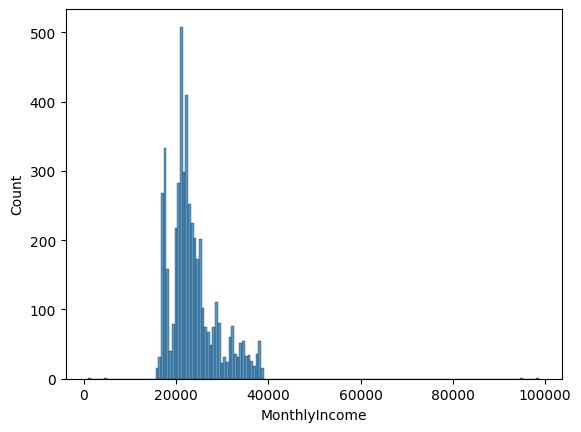

In [63]:
sns.histplot(df['MonthlyIncome']);

In [64]:
df[df['MonthlyIncome'] > 40000]

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
38,0,36.0,Self Enquiry,1,11.0,Salaried,Female,2,4.0,Basic,3.0,Divorced,1.0,1,2,1,0.0,Executive,95000.0
2482,0,37.0,Self Enquiry,1,12.0,Salaried,Female,3,5.0,Basic,5.0,Divorced,2.0,1,2,1,1.0,Executive,98678.0


In [65]:
df[df['MonthlyIncome'] < 10000]

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
142,0,38.0,Self Enquiry,1,9.0,Large Business,Female,2,3.0,Deluxe,3.0,Single,4.0,1,5,0,0.0,Manager,1000.0
2586,0,39.0,Self Enquiry,1,10.0,Large Business,Female,3,4.0,Deluxe,3.0,Single,5.0,1,5,0,1.0,Manager,4678.0


Technically, any value for MonthlyIncome is justifiable, as a person could be making any amount of money. This is especially true for values above the upper fence, as the goal of the model is to determine whether a customer would purchase a vacation package from an agency; rich people are more well-situated to be able to purchase a vacation package, so it makes sense for some values to be surprisingly high. Values <i>below</i> the lower fence, however, are not nearly as believable, or useful, as there are likely outside circumstances that allow for these people to be able to purchase the package, which is outside the scope of the dataset. For that reason, only the lower values will be replaced with the column's median.

In [66]:
df.loc[df['MonthlyIncome'] < 10000, ['MonthlyIncome']] = 22347

In [67]:
df[df['MonthlyIncome'] < 10000]

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome


### Inconsistent Data

We need to check any categorical columns that take string values as input.

<b>Columns to Check:</b>
<ul>
    <li>TypeofContact</li>
    <li>Occupation</li>
    <li>Gender</li>
    <li>ProductPitched</li>
    <li>MaritalStatus</li>
    <li>Designation</li>
</ul>

In [68]:
cols = ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
        'MaritalStatus', 'Designation']

for col in cols:
    print(f'{df[col].value_counts()} \n')

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64 

Occupation
Salaried          2363
Small Business    2064
Large Business     434
Free Lancer          2
Name: count, dtype: int64 

Gender
Male       2901
Female     1807
Fe Male     155
Name: count, dtype: int64 

ProductPitched
Basic           1832
Deluxe          1717
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64 

MaritalStatus
Married      2325
Divorced      944
Single        912
Unmarried     682
Name: count, dtype: int64 

Designation
Executive         1832
Manager           1717
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64 



#### Replacing Inconsistencies

The only column with inconsistent data is Gender

In [69]:
df.loc[df['Gender'] == 'Fe Male', ['Gender']] = 'Female'

In [70]:
df['Gender'].value_counts()

Gender
Male      2901
Female    1962
Name: count, dtype: int64

## Exploratory Data Analysis

#### Functions

In [71]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    data[feature].describe()
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [72]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [73]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [74]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

Categorical features


- ProdTaken
- TypeofContact
- CityTier
- Occupation
- Gender
- ProductPitched
- PitchSatisfactionScore
- MaritalStatus
- Passport
- OwnCar
- Designation

ProdTaken Analysis

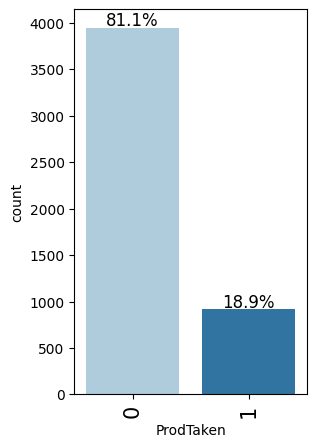

In [75]:
labeled_barplot(df, 'ProdTaken', perc=True)

Observations:
- Majority of people did not buy the package

TypeOfContace Analysis

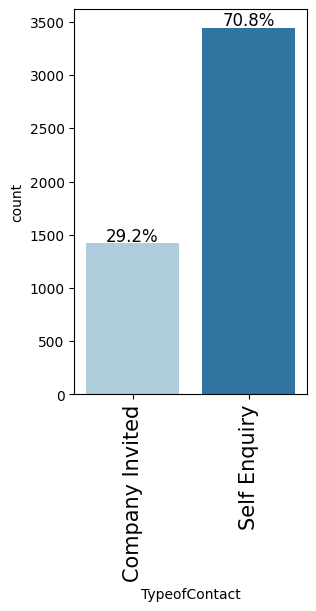

In [76]:
labeled_barplot(df, 'TypeofContact', perc=True)

Observations:
- 70 percent of people went out of their own interest
- Roughly 30 percent of people were invited by the company

CityTier analysis

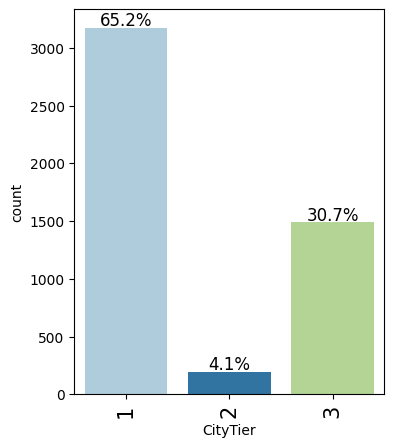

In [77]:
labeled_barplot(df, 'CityTier', perc=True)

Observations:
- Majority are in tier 1 with 65 percent
- Small amount are in tier 2 at 4 percent
- 30 percent of people in tier 3 cities

Occupation Analysis

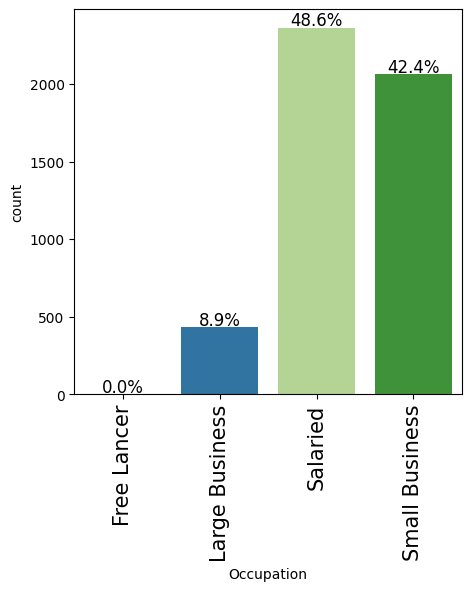

In [78]:
labeled_barplot(df, 'Occupation', perc=True)

Observations:
- Only two free lancers total very small percentage
- Roughly even split betwen salaried and small business being 48% and 42%
- Small amount of large business people total make up is 8.9%

Gender Analysis

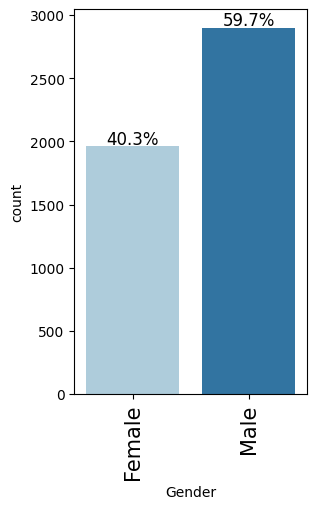

In [79]:
labeled_barplot(df, 'Gender', perc=True)

Observations:
- 60 percent of values are male
- 40 percent of values are female

Product Pitched Analysis

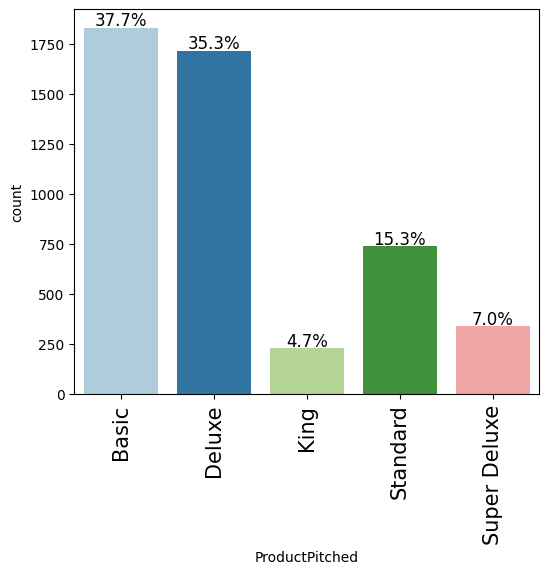

In [80]:
labeled_barplot(df, 'ProductPitched', perc=True)

Observations:
- Even split of 35% between basic and deluxe product
- 5% are pitched king
- 7% are pitched super deluxed
- 15% are pithced standard. Are standard and basic the same thing?

Pitch Satisfaction Score analysis

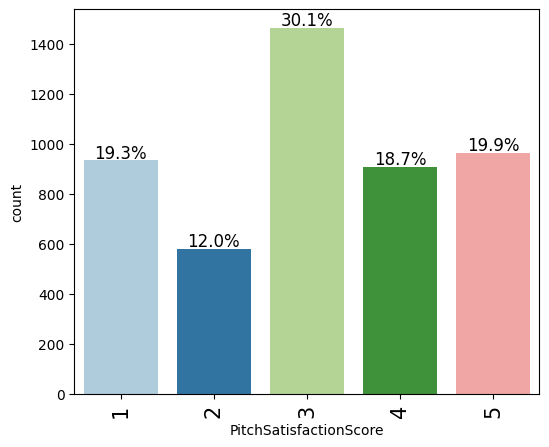

In [81]:
labeled_barplot(df, 'PitchSatisfactionScore', perc=True)

Observations:
- Roughly 20 percent split between score of 1,4, and 5
- 30 percent rated it a 3
- 12 percent rated the pitch at a 2

Marital Status Analysis

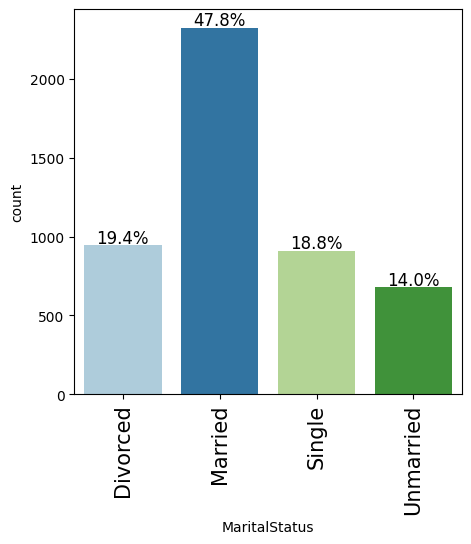

In [82]:
labeled_barplot(df, 'MaritalStatus', perc=True)

Observations
- 50 percent of people are married
- both divorced and single have 20 percent 
- 14 percent are unmarried
- I wonder if unmarried stands for dating. Room for feature engineering.

Passport Analysis

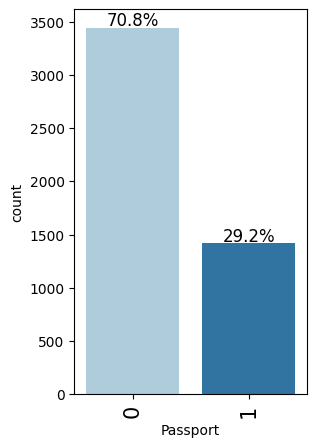

In [83]:
labeled_barplot(df, 'Passport', perc=True)

Observations
- 70 percent of people do not have a passport
- 30 percent of people have a passport

OwnCar Analysis

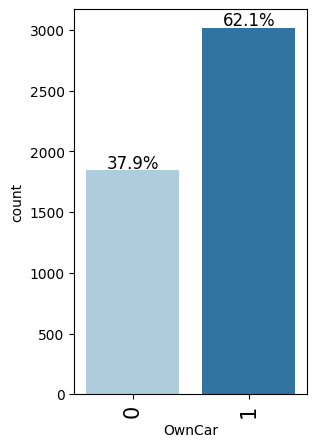

In [84]:
labeled_barplot(df, 'OwnCar', perc=True)

Observations:
- 38 percent of people do not own a car
- 62 percent of people do own a car

Designation Analysis

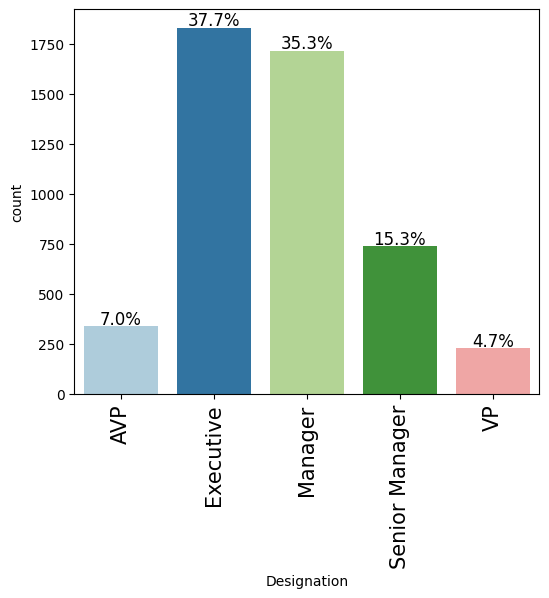

In [85]:
labeled_barplot(df, 'Designation', perc=True)

Observations:
- Roughly 35 percent of people are executives
- Roughly 35 percent of people are managers
- AVP and VP have the lowest percentages of entries
- Senior manager is 15 percent of values

### Numerical Analysis

#### Age

In [86]:
df['Age'].describe()

count    4863.000000
mean       37.585647
std         9.104766
min        18.000000
25%        31.000000
50%        36.000000
75%        43.000000
max        61.000000
Name: Age, dtype: float64

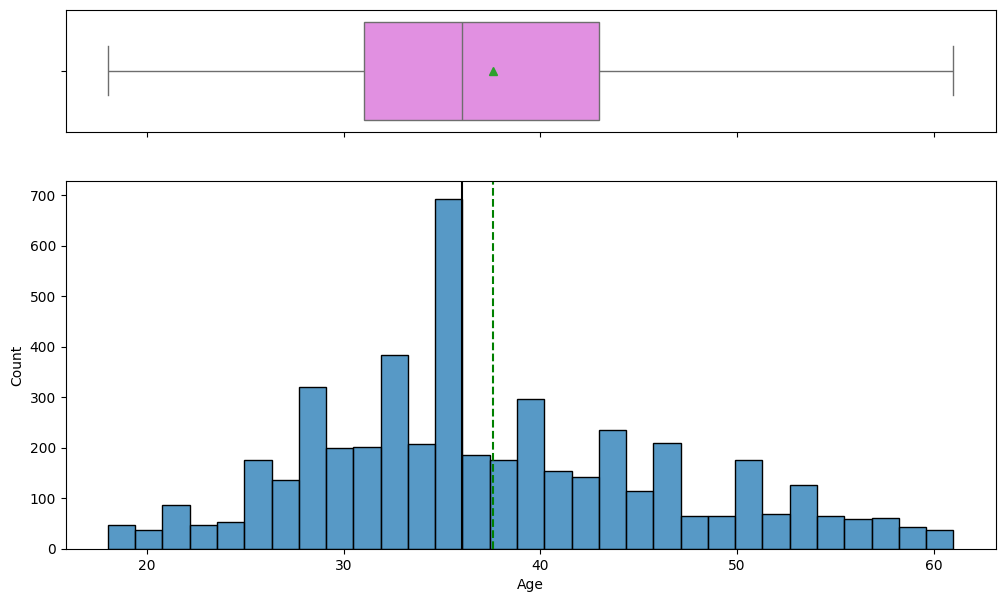

In [87]:
histogram_boxplot(df, 'Age');

In [88]:
df['Age'].mode()

0    36.0
Name: Age, dtype: float64

<b>Observations:</b>
- Age: Mean=38.59 Median=36 Mode=36 Range=18-61
- The distribution isn't as highly skewed right as one would normally expect for age, but this makes sense, given the entries consist mostly of middle-upper middle class individuals
- Mean > Median

#### Duration of Pitch

In [89]:
df['DurationOfPitch'].describe()

count    4863.000000
mean       15.328398
std         8.025317
min         5.000000
25%         9.000000
50%        13.000000
75%        19.000000
max        36.000000
Name: DurationOfPitch, dtype: float64

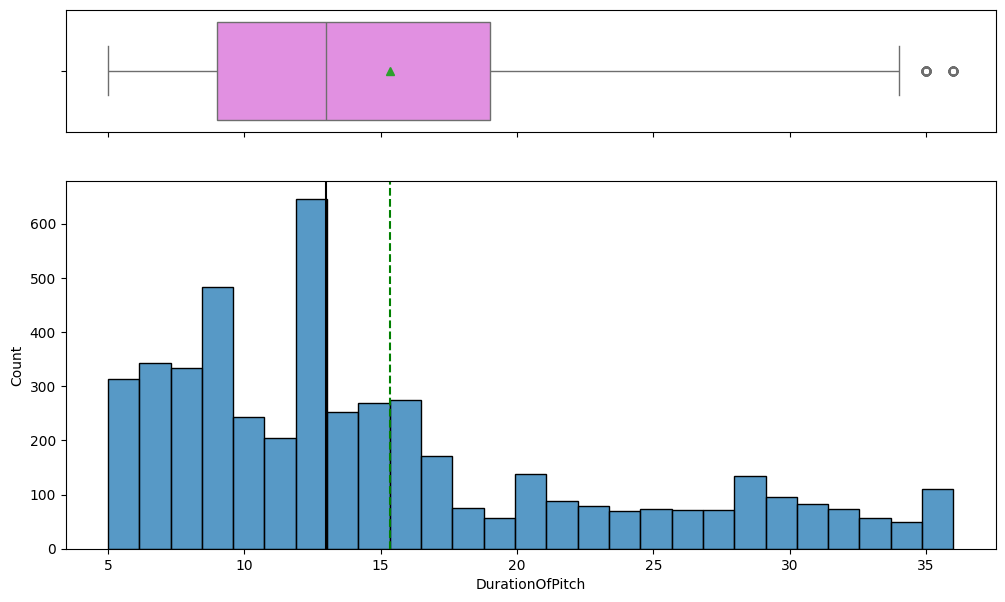

In [90]:
histogram_boxplot(df, 'DurationOfPitch');

In [91]:
df['DurationOfPitch'].mode()

0    9.0
Name: DurationOfPitch, dtype: float64

<b>Observations:</b>
- DurationOfPitch: Mean=15.33 Median=13 Mode=9 Range=5-36
- Heavily skewed right
- Mean > Median, and both are considerably higher than Mode

#### Number of Person Visiting

In [92]:
df['NumberOfPersonVisiting'].describe()

count    4863.000000
mean        2.908081
std         0.724762
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         5.000000
Name: NumberOfPersonVisiting, dtype: float64

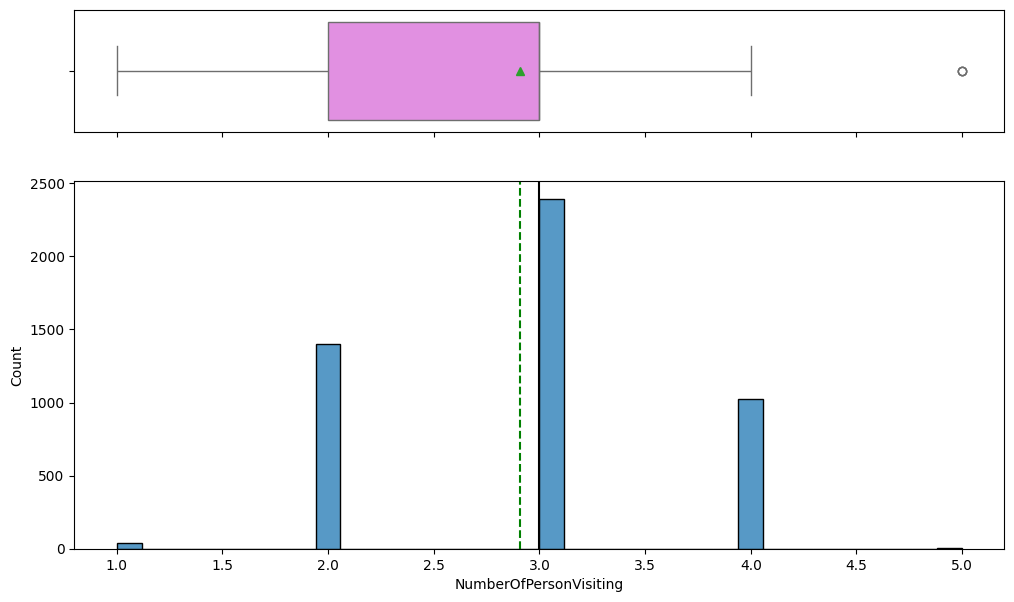

In [93]:
histogram_boxplot(df, 'NumberOfPersonVisiting');

In [94]:
df['NumberOfPersonVisiting'].mode()

0    3
Name: NumberOfPersonVisiting, dtype: int64

<b>Observations:</b>
- NumberOfPersonVisiting: Mean=2.91 Median=3 Mode=3 Range=1-5
- Relatively normal distribution, with some slight skew right
- Mean, Median, and Mode are all practically the same (3)

#### Number of Followups

In [95]:
df['NumberOfFollowups'].describe()

count    4863.000000
mean        3.713346
std         0.996539
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         6.000000
Name: NumberOfFollowups, dtype: float64

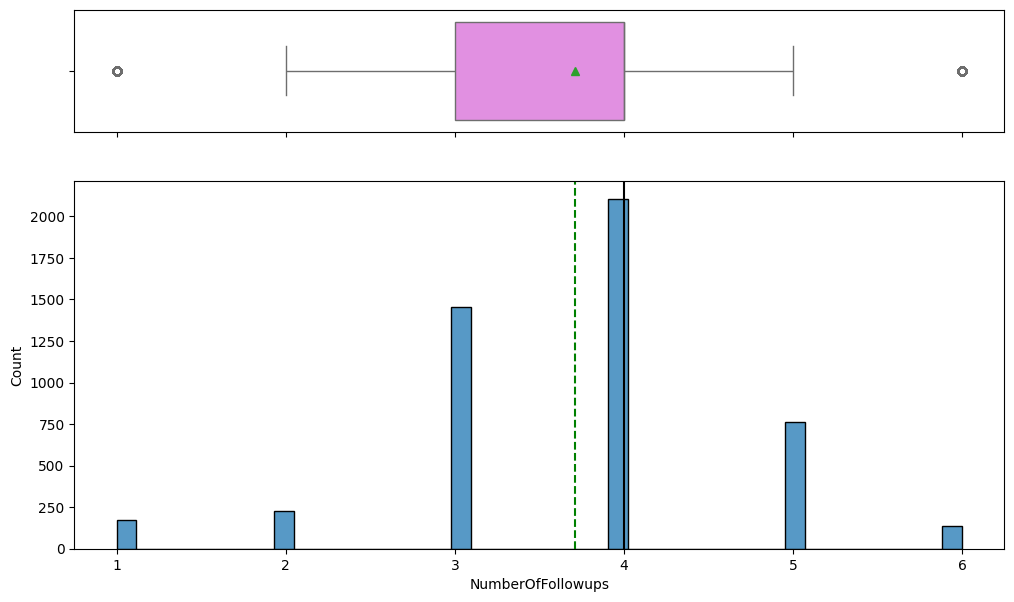

In [96]:
histogram_boxplot(df, 'NumberOfFollowups');

In [97]:
df['NumberOfFollowups'].mode()

0    4.0
Name: NumberOfFollowups, dtype: float64

<b>Observations:</b>
- NumberOfFollowups: Mean=3.71 Median=4 Mode=4 Range=1-6
- Slightly skewed left
- Median > Mean = Mode
- Data heavily clustered in the center (3-4)

#### Number of Trips

In [98]:
df['NumberOfTrips'].describe()

count    4863.000000
mean        3.216944
std         1.753654
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         8.000000
Name: NumberOfTrips, dtype: float64

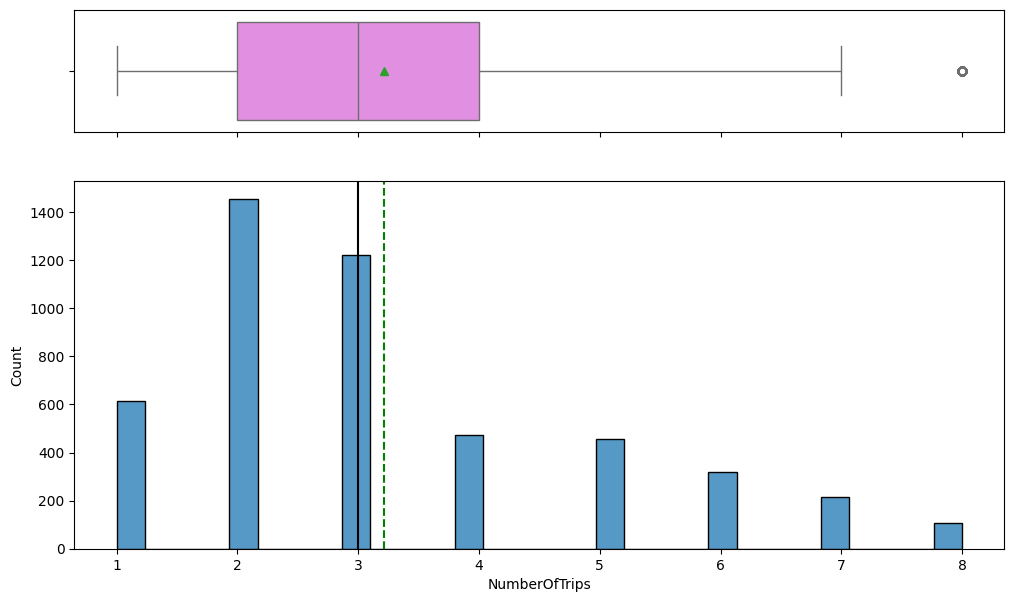

In [99]:
histogram_boxplot(df, 'NumberOfTrips');

In [100]:
df['NumberOfTrips'].mode()

0    2.0
Name: NumberOfTrips, dtype: float64

<b>Observations:</b>
- NumberOfTrips: Mean=3.22 Median=3 Mode=2 Range=1-8
- Heavily skewed right
- Clustered mostly around 2-3
- Mean > Median > Mode

#### Number of Children Visiting

In [101]:
df['NumberOfChildrenVisiting'].describe()

count    4863.000000
mean        1.187744
std         0.852271
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: NumberOfChildrenVisiting, dtype: float64

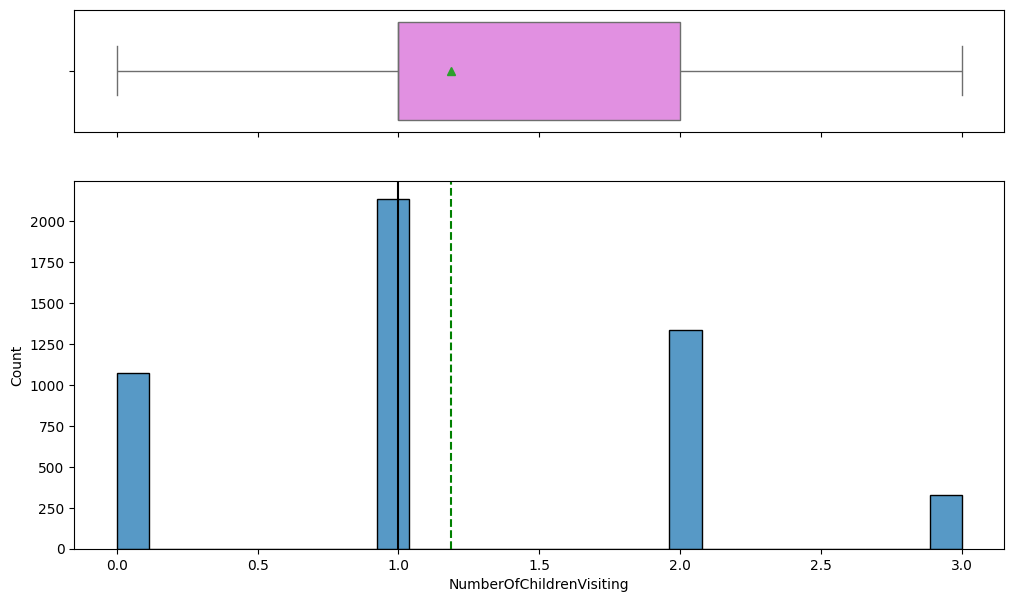

In [102]:
histogram_boxplot(df, 'NumberOfChildrenVisiting');

In [103]:
df['NumberOfChildrenVisiting'].mode()

0    1.0
Name: NumberOfChildrenVisiting, dtype: float64

<b>Observations:</b>
- NumberOfChildrenVisiting: Mean=1.19 Median=1 Mode=1 Range=0-3
- Skewed right
- Mean > Median = Mode
- It is rare for there to ever be more than two children visiting

#### Monthly Income

In [104]:
df['MonthlyIncome'].describe()

count     4863.000000
mean     23573.434094
std       5253.772112
min      16009.000000
25%      20483.000000
50%      22347.000000
75%      25447.500000
max      98678.000000
Name: MonthlyIncome, dtype: float64

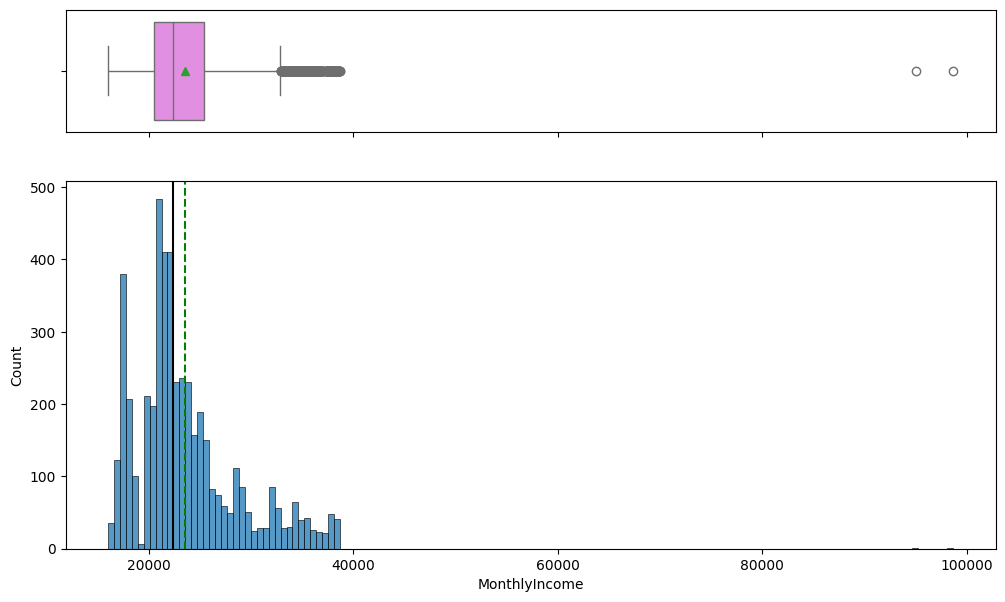

In [105]:
histogram_boxplot(df, 'MonthlyIncome');

In [106]:
df['MonthlyIncome'].mode()

0    22347.0
Name: MonthlyIncome, dtype: float64

<b>Observations:</b>
- MonthlyIncome: Mean=23573.43 Median=22347 Mode=22347 Range=16009-98678
- Very heavily skewed right, even excluding the two remaining outliers
- Jarring dropoff in entry count just below 20000, then sharp increase
- Mean > Median = Mode

#### Preferred Property Star

In [107]:
df['PreferredPropertyStar'].describe()

count    4863.000000
mean        3.578655
std         0.796907
min         3.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: PreferredPropertyStar, dtype: float64

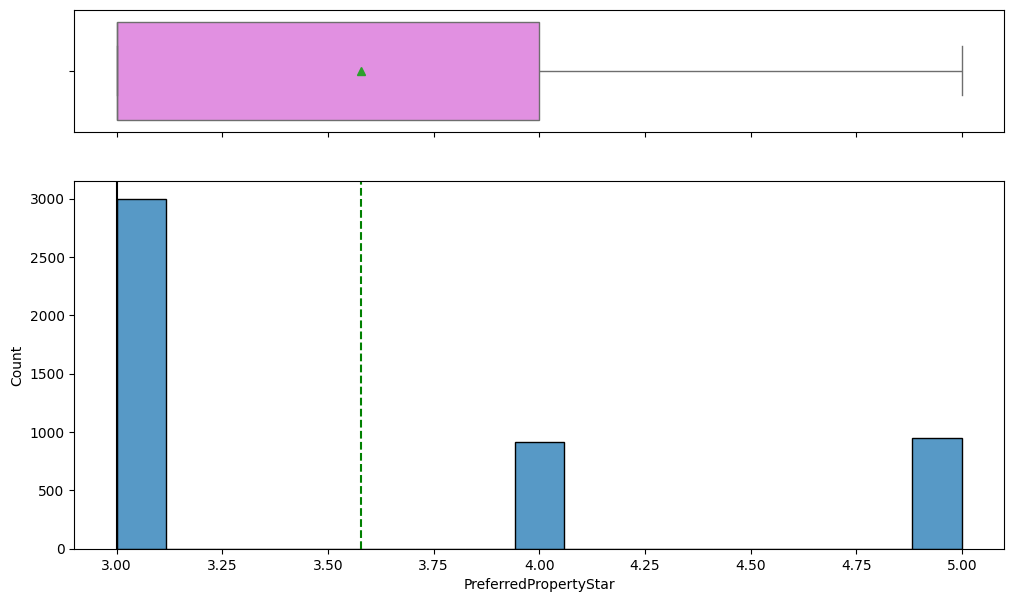

In [108]:
histogram_boxplot(df, 'PreferredPropertyStar');

In [109]:
df['PreferredPropertyStar'].mode()

0    3.0
Name: PreferredPropertyStar, dtype: float64

<b>Observations:</b>
- PreferredPropertyStar: Mean=3.58 Median=3 Mode=3 Range=3-5
- No entries at 1 or 2 stars
- Heavily skewed right, with most entries being at a value of 3
- Mean > Median = Mode

### MultiVariate Analysis

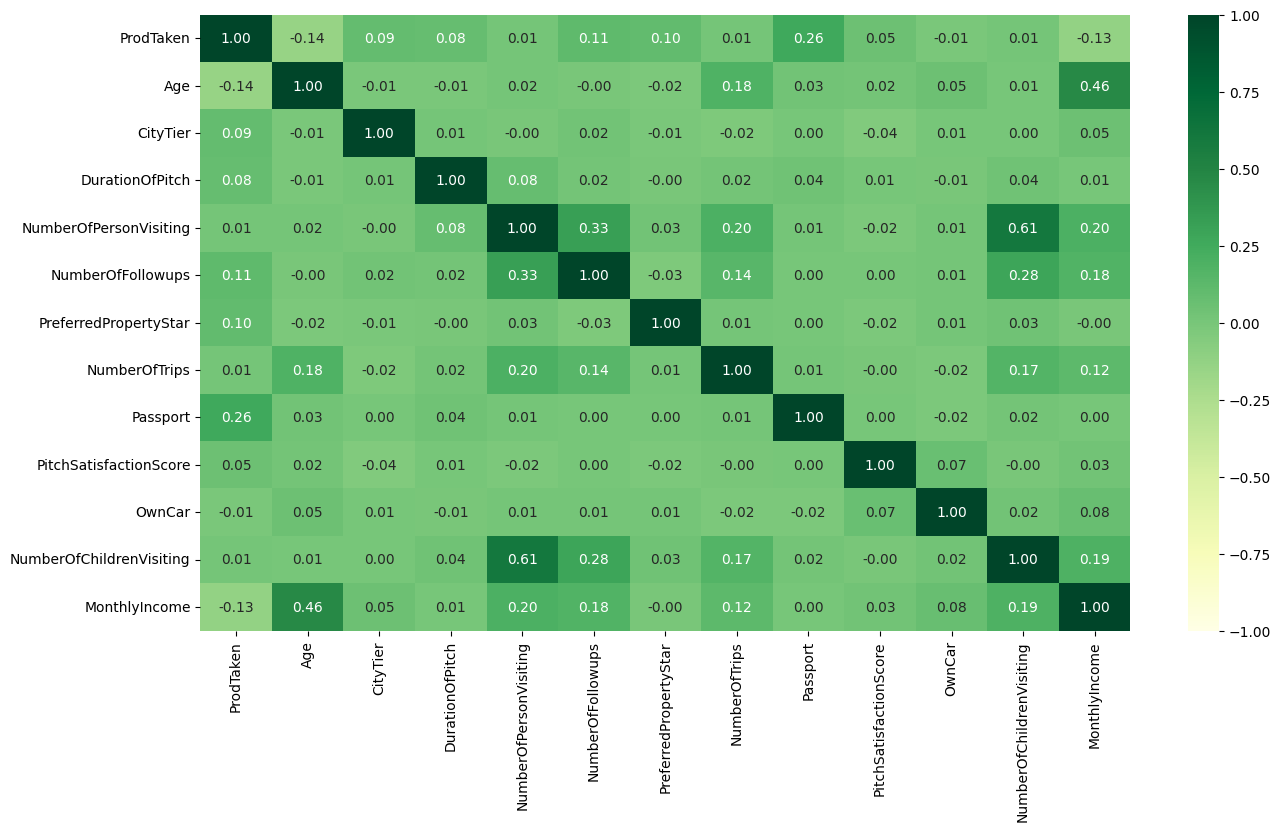

In [110]:
# Correlation heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="YlGn")
plt.show()

<b>Observations:</b>
- Positive Correlation of .61 betweeen Number of Children Visiting and Number of Person Visiting
- .46 correlation between age and monthly income
- slight negative correlation between age and prod taken
- Number of Followups and Number of people Visiting are positively correlated by .33
- Everything else shows little to no correlation

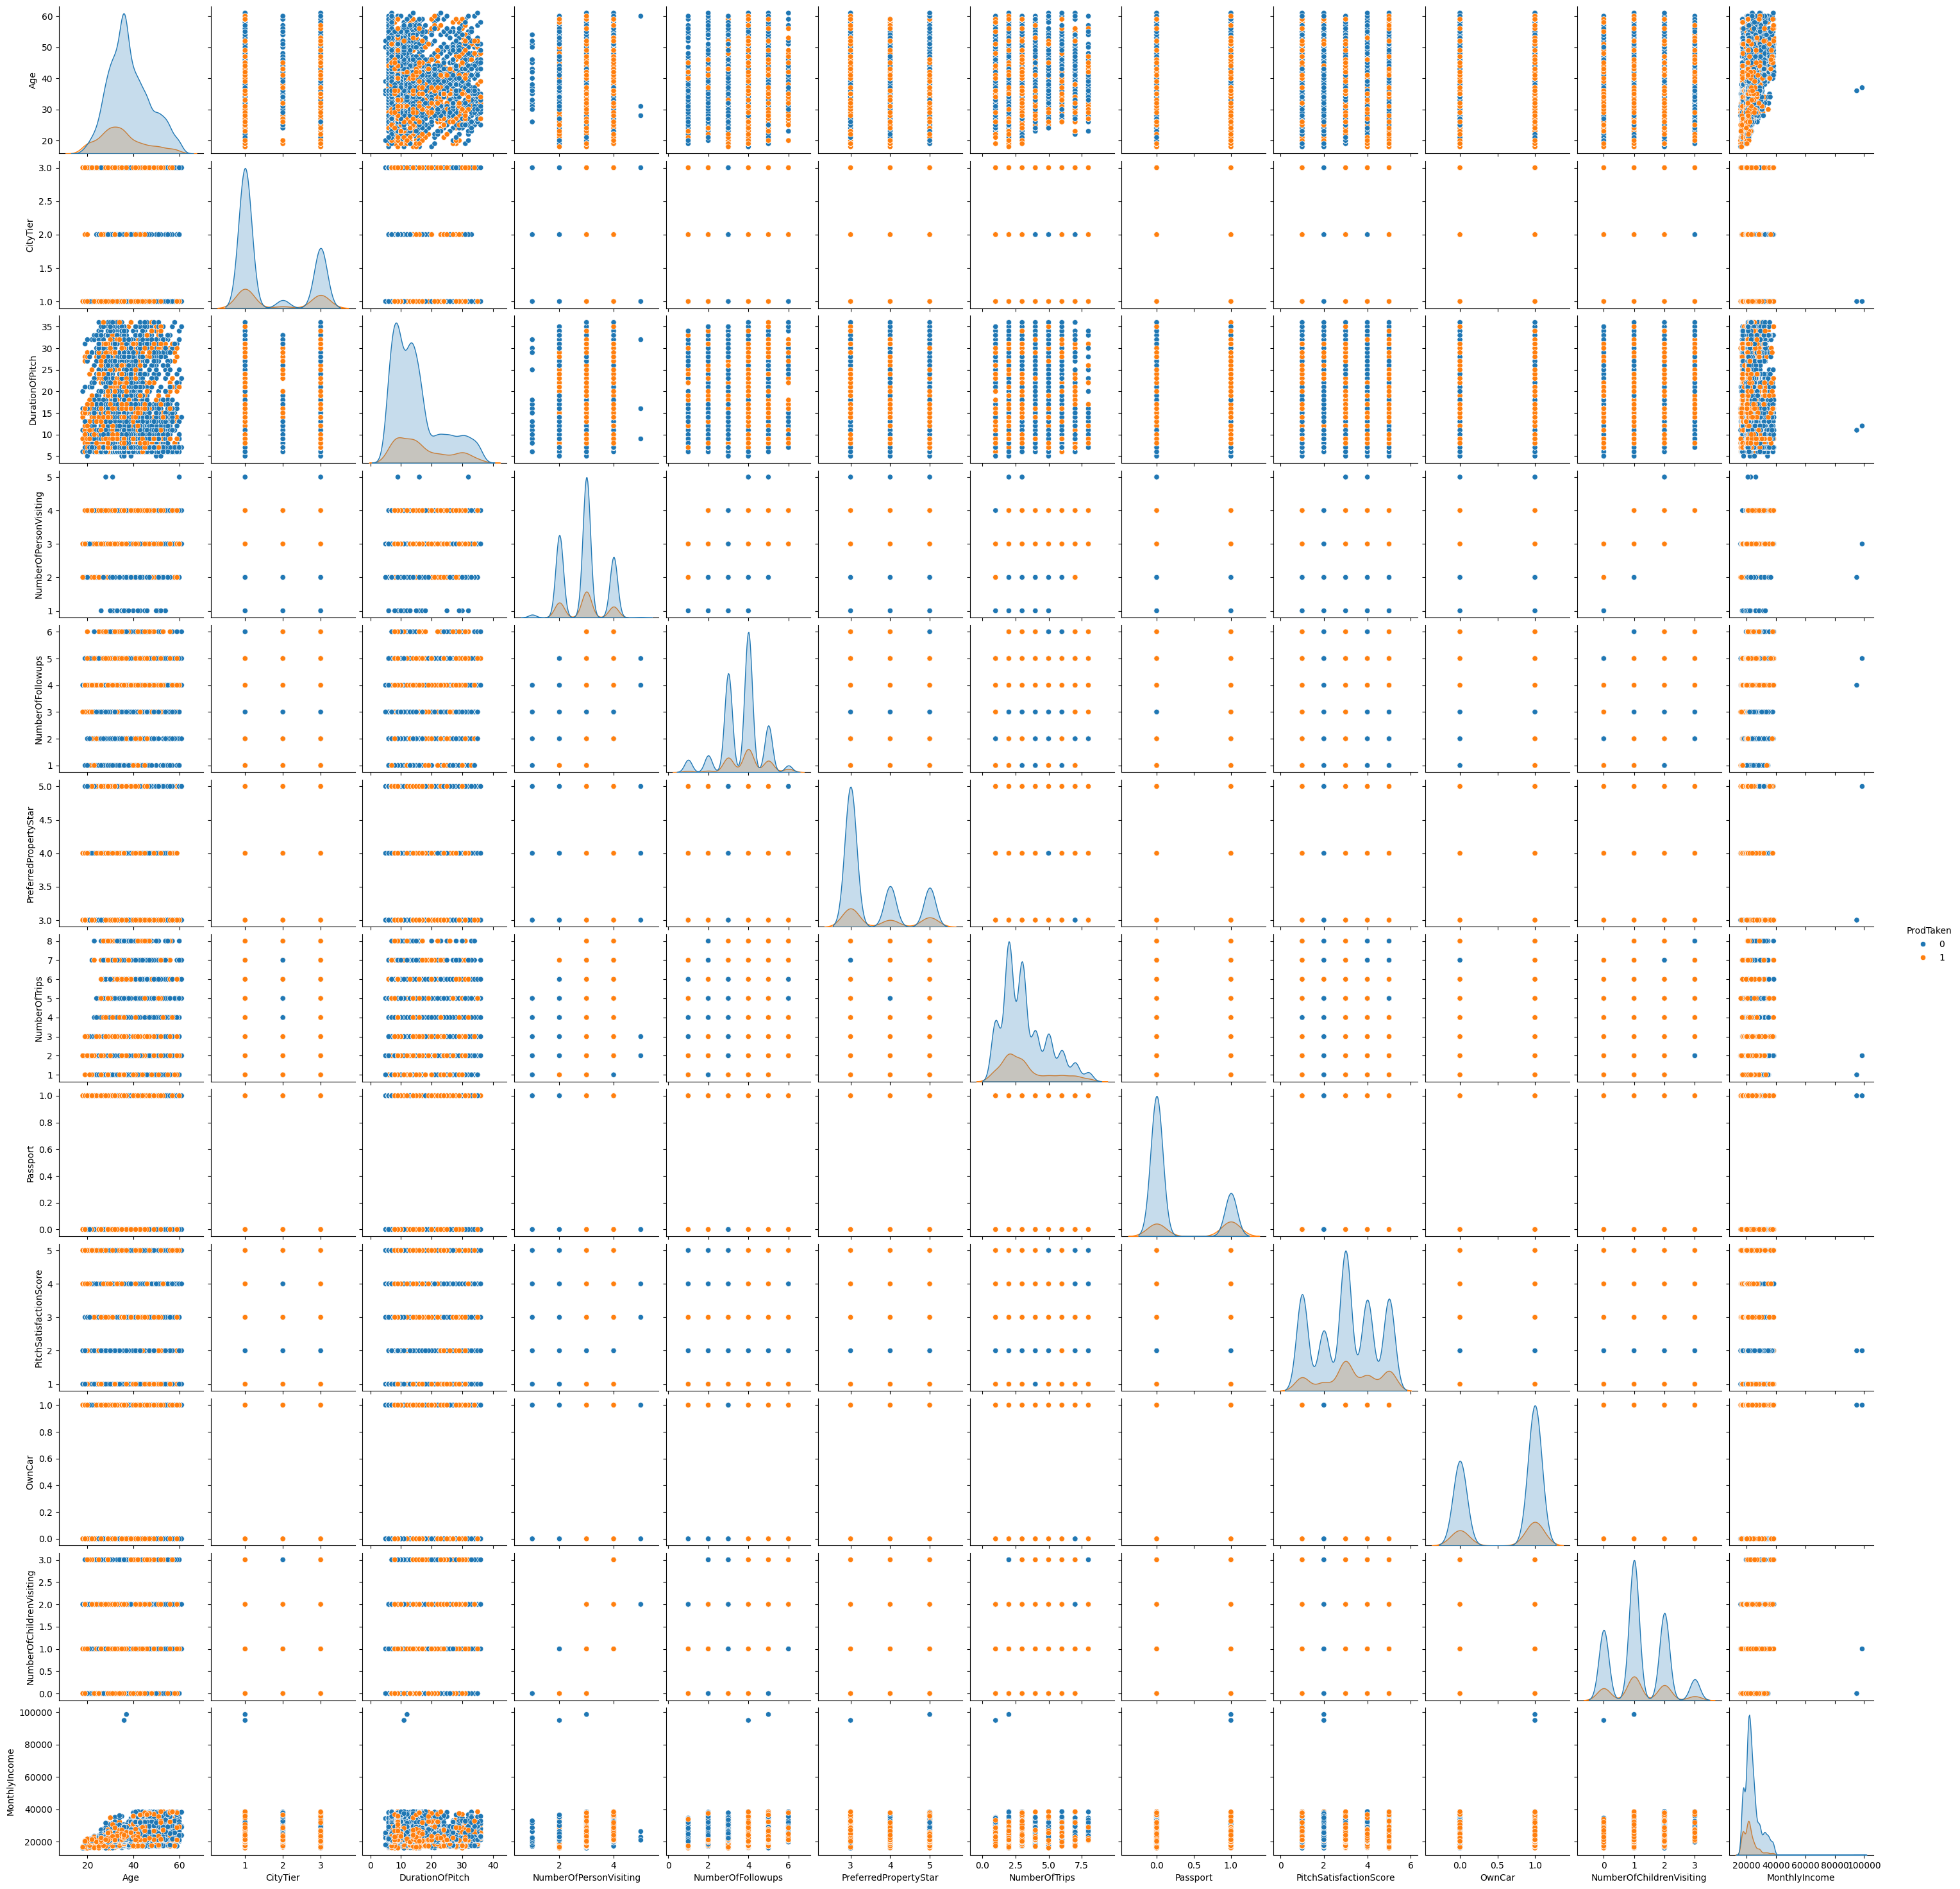

In [111]:
# Numeric variables based on income
sns.pairplot(data=df,hue='ProdTaken')


ProdTaken X TypeofContact

ProdTaken           0    1   All
TypeofContact                   
All              3946  917  4863
Self Enquiry     2837  607  3444
Company Invited  1109  310  1419
------------------------------------------------------------------------------------------------------------------------


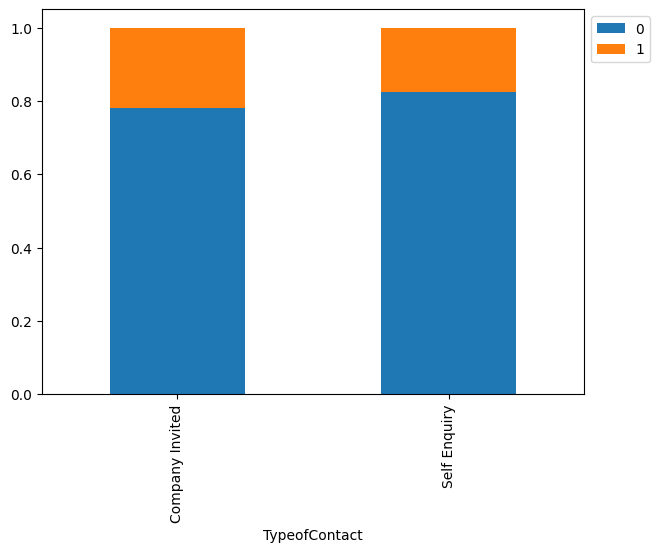

In [112]:
stacked_barplot(df, 'TypeofContact', 'ProdTaken')

<b>Observation</b>
- Slighlty more people who were company invited took the product
- Slighlty less people who self inquired took the product

ProdTaken x CityTier

ProdTaken     0    1   All
CityTier                  
All        3946  917  4863
1          2655  518  3173
3          1139  353  1492
2           152   46   198
------------------------------------------------------------------------------------------------------------------------


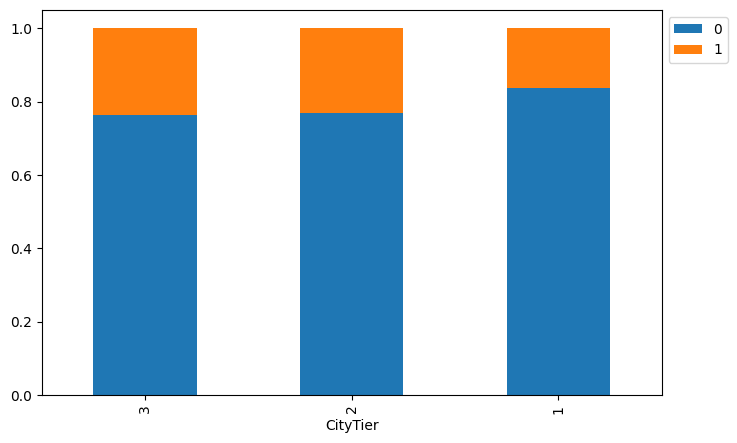

In [113]:
stacked_barplot(df, 'CityTier', 'ProdTaken')

<b>Observation:</b>
- City tier 2 and 3 both have similar values for those who take and dont
- City tier 1 has slightly less products taken

ProdTaken x Occupation

ProdTaken          0    1   All
Occupation                     
All             3946  917  4863
Salaried        1950  413  2363
Small Business  1682  382  2064
Large Business   314  120   434
Free Lancer        0    2     2
------------------------------------------------------------------------------------------------------------------------


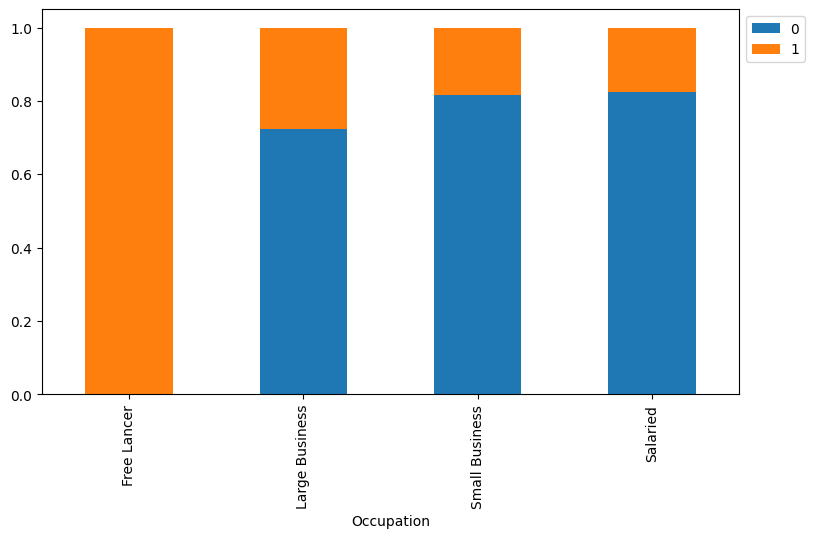

In [114]:
stacked_barplot(df, 'Occupation', 'ProdTaken')

<b>Observations</b>
- Both of the free lancers took the product
- Slightly more of a percentage of large business people took the product
- Roughly same amount of people took the product in small business and salaried

ProdTaken x Gender

ProdTaken     0    1   All
Gender                    
All        3946  917  4863
Male       2326  575  2901
Female     1620  342  1962
------------------------------------------------------------------------------------------------------------------------


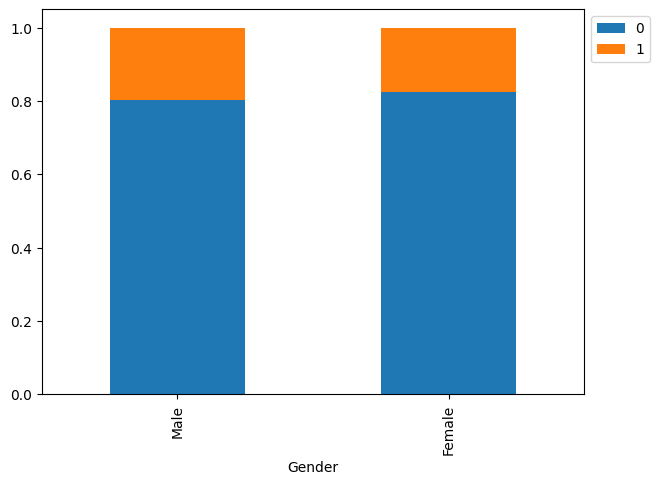

In [115]:
stacked_barplot(df, 'Gender', 'ProdTaken')

<b>Observation:</b>
- Roughly same percentage of males and females took the product
- Males percentage wise took the product more

ProdTaken x ProductPitched

ProdTaken          0    1   All
ProductPitched                 
All             3946  917  4863
Basic           1283  549  1832
Deluxe          1513  204  1717
Standard         618  124   742
King             210   20   230
Super Deluxe     322   20   342
------------------------------------------------------------------------------------------------------------------------


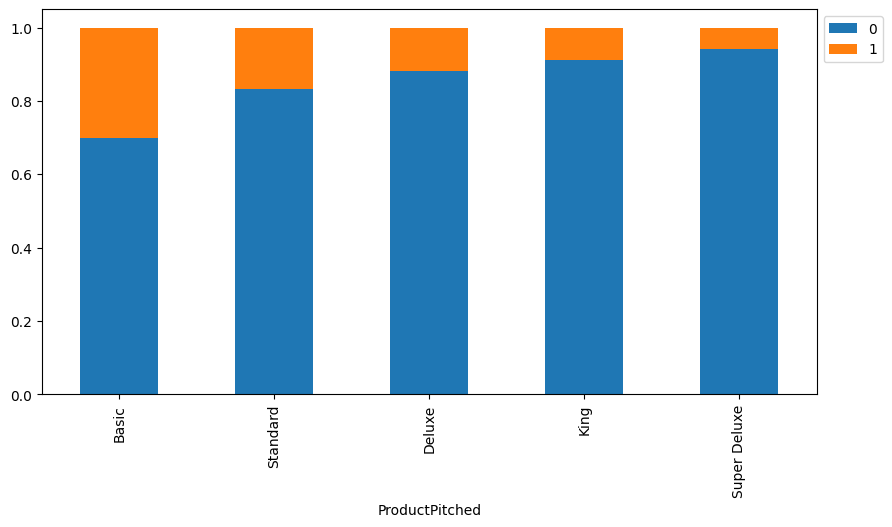

In [116]:
stacked_barplot(df, 'ProductPitched', 'ProdTaken')

<b>Observations</b>
- Basic had the highest percentage of people take the product
- Order from greatest to least product taken: Basic, Standard, Deluxe, King, Super Deluxe

ProdTaken x PitchSatisfactionScore

ProdTaken                  0    1   All
PitchSatisfactionScore                 
All                     3946  917  4863
3                       1152  314  1466
5                        757  210   967
4                        748  162   910
1                        794  143   937
2                        495   88   583
------------------------------------------------------------------------------------------------------------------------


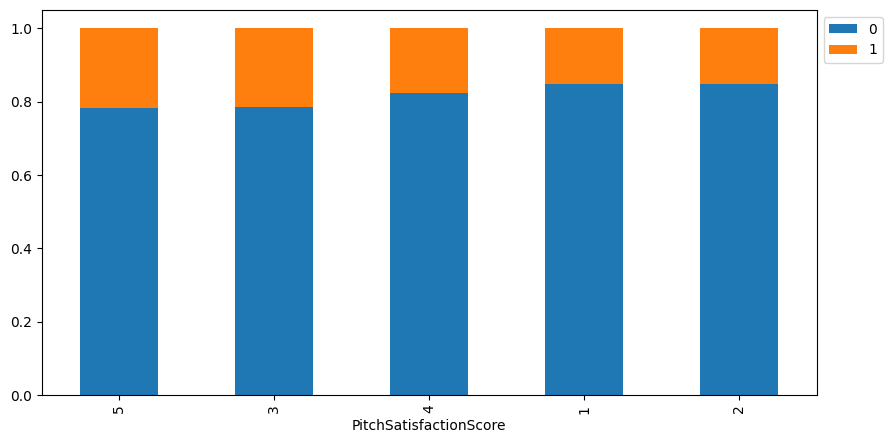

In [117]:
stacked_barplot(df, 'PitchSatisfactionScore', 'ProdTaken')

<b>Observations:</b>
- Highest percentage of people who took the product rated the pitch at 5, 3 is a clos e second
- 4,1,and 2 all have similar percentages of who took the product

ProdTaken x MaritalStatus

ProdTaken         0    1   All
MaritalStatus                 
All            3946  917  4863
Married        1999  326  2325
Single          610  302   912
Unmarried       516  166   682
Divorced        821  123   944
------------------------------------------------------------------------------------------------------------------------


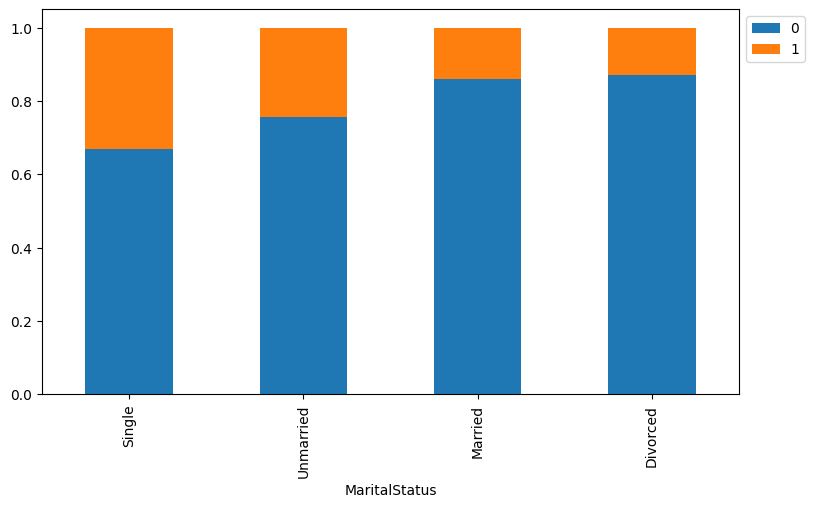

In [118]:
stacked_barplot(df, 'MaritalStatus', 'ProdTaken')

<b>Observations:</b>
- Single had the highest percentage of product taken
- Unmarried had the next highest
- Married and divorced were similar and had the lowest percentage product taken

ProdTaken x Passport

ProdTaken     0    1   All
Passport                  
All        3946  917  4863
1           928  494  1422
0          3018  423  3441
------------------------------------------------------------------------------------------------------------------------


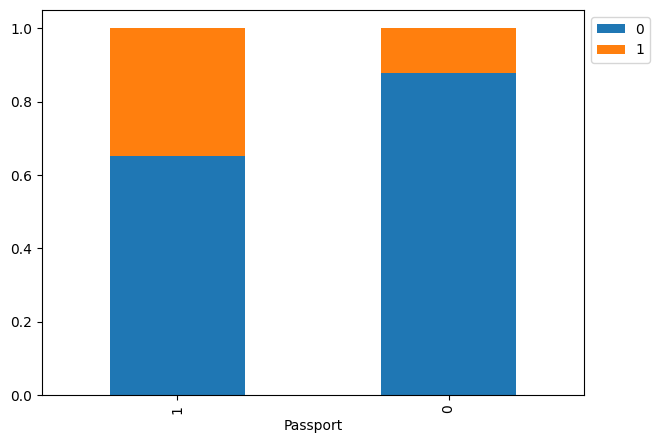

In [119]:
stacked_barplot(df, 'Passport', 'ProdTaken')

<b>Observations:</b>
- Around roughly double people with passports took the product compared to those without.

ProdTaken X OwnCar

ProdTaken     0    1   All
OwnCar                    
All        3946  917  4863
1          2460  558  3018
0          1486  359  1845
------------------------------------------------------------------------------------------------------------------------


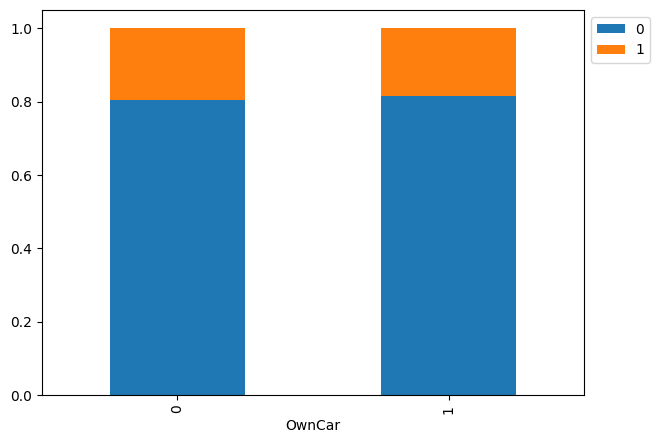

In [120]:
stacked_barplot(df, 'OwnCar', 'ProdTaken')

<b>Observations</b>
- Same percentage of people who do or dont own a car took the product

ProdTaken x Designation

ProdTaken          0    1   All
Designation                    
All             3946  917  4863
Executive       1283  549  1832
Manager         1513  204  1717
Senior Manager   618  124   742
AVP              322   20   342
VP               210   20   230
------------------------------------------------------------------------------------------------------------------------


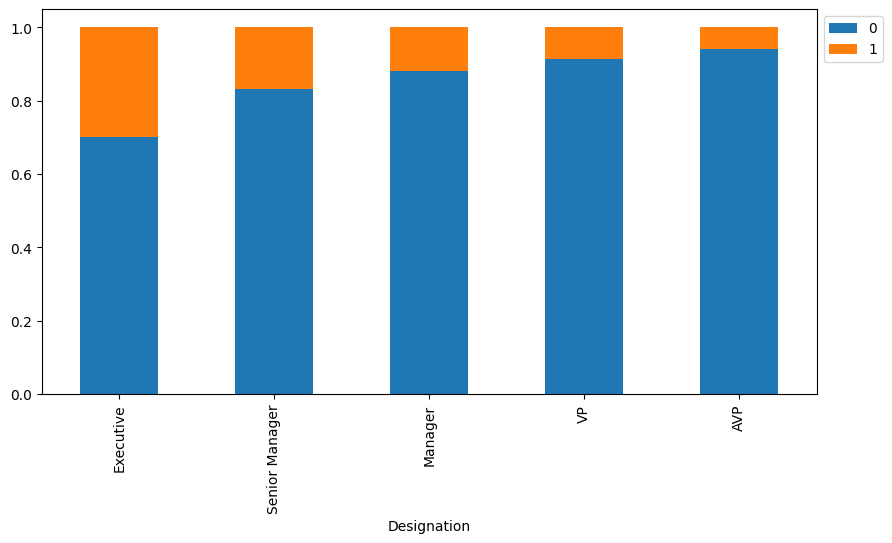

In [121]:
stacked_barplot(df, 'Designation', 'ProdTaken')

<b>Observations</b>
- Executive had roughly double the percentage take the product
- Sales manager had the next most
- Manager, Vp, and AVP all had similar and the lowest percentage of people take the product.

#### ProdTaken x Age

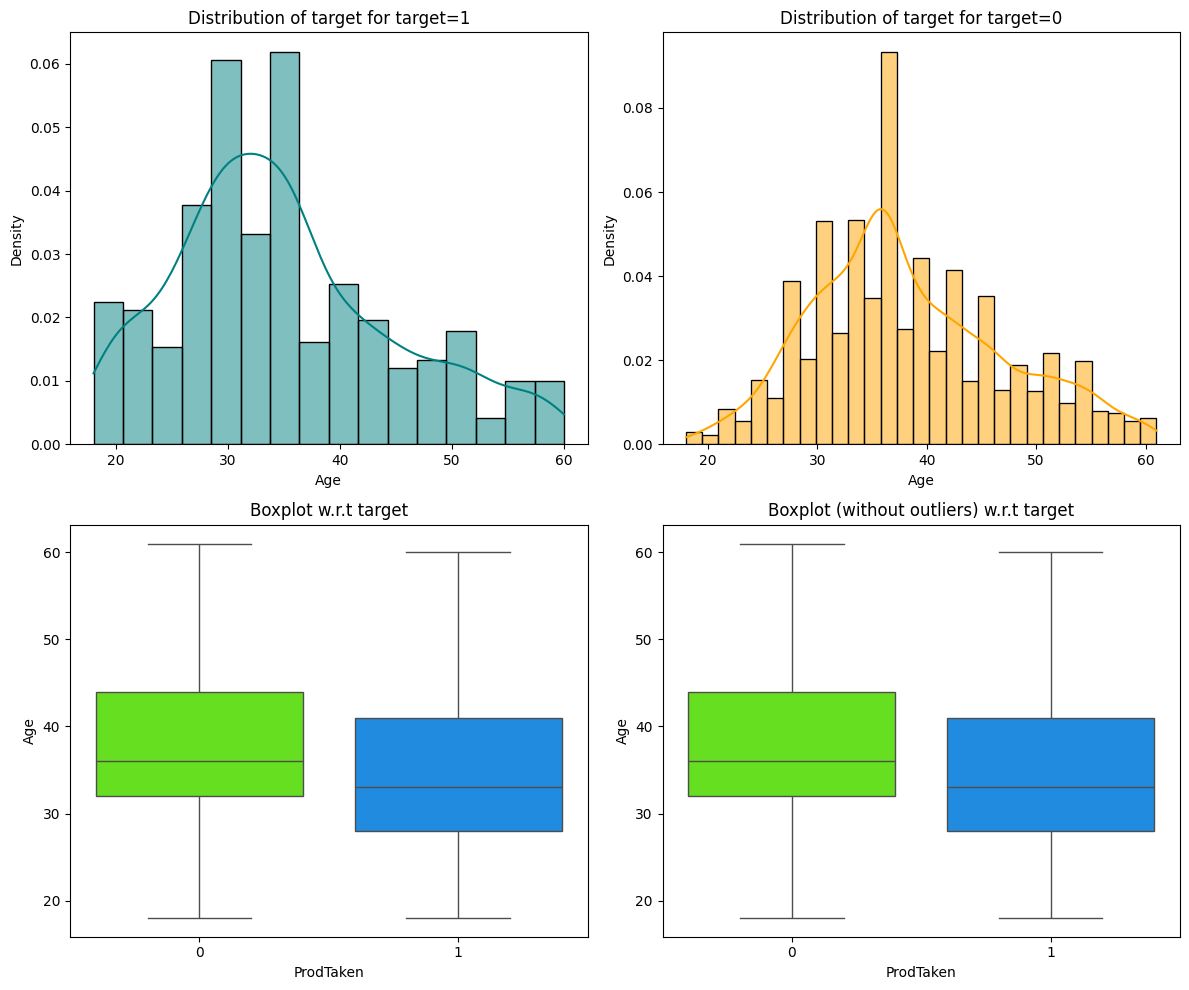

In [122]:
distribution_plot_wrt_target(df, 'Age', 'ProdTaken')

<b>Observation:</b> The two distributions are similar, however, there is a noticeable difference in the average age of the two sides. It seems those who took the vacation package are slightly younger, on average.

#### ProdTaken x DurationOfPitch

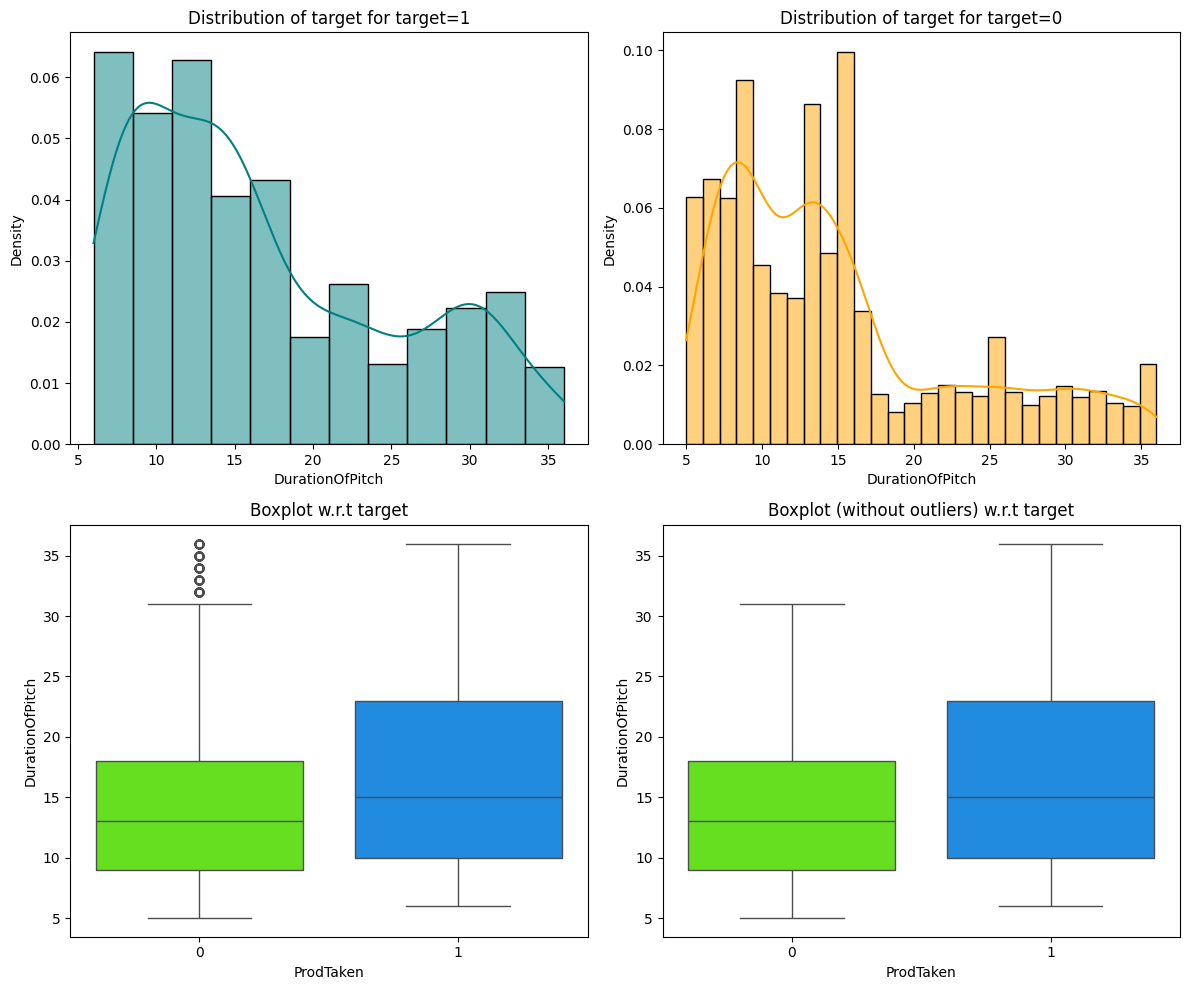

In [123]:
distribution_plot_wrt_target(df, 'DurationOfPitch', 'ProdTaken')

<b>Observation:</b> There does not appear to be a very large difference between the two distributions. If anything, the group who took the vacation package experienced slightly longer pitch durations.

#### ProdTaken x NumberOfPersonVisiting

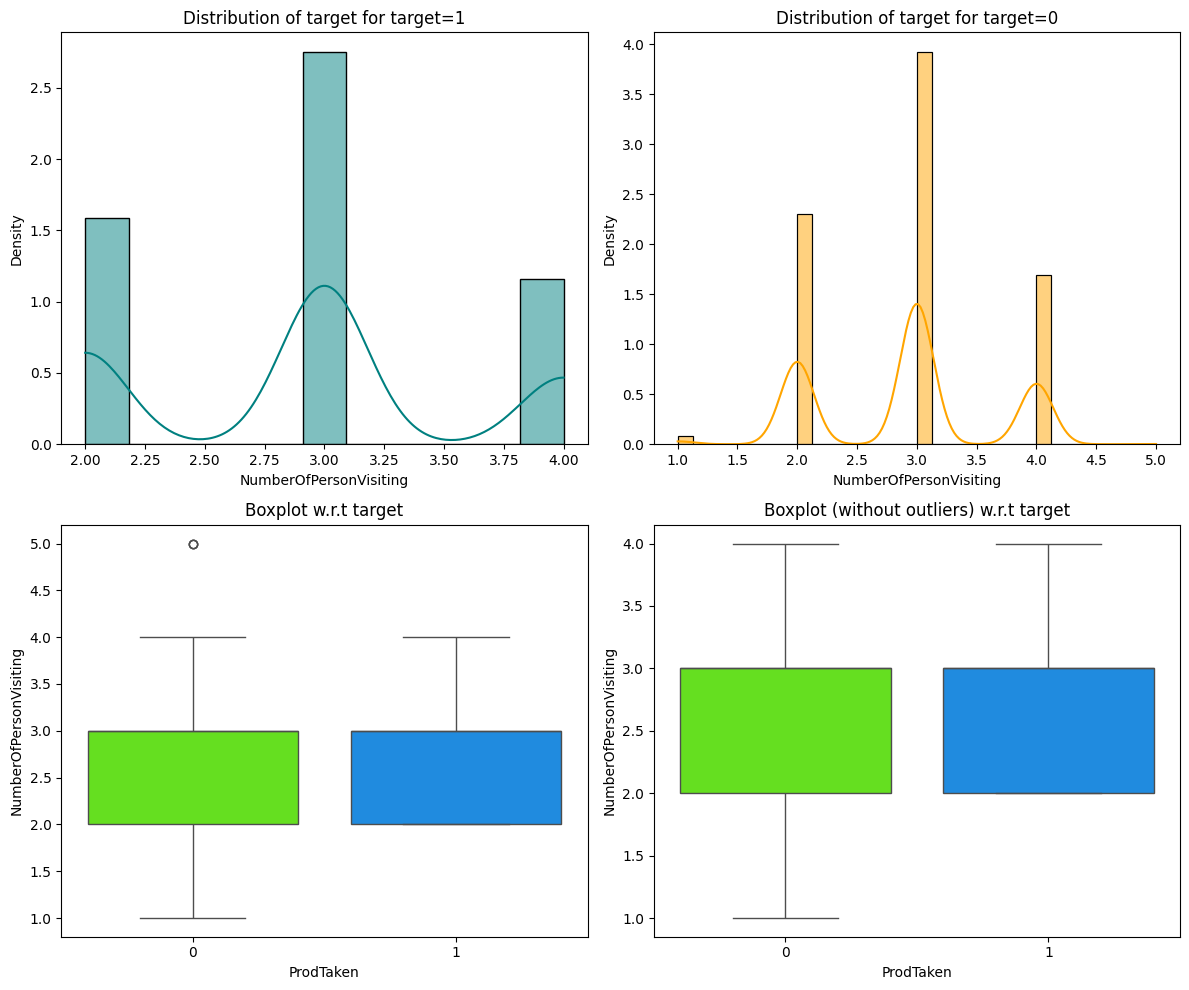

In [124]:
distribution_plot_wrt_target(df, 'NumberOfPersonVisiting', 'ProdTaken')

<b>Observation:</b> There is not a considerable difference between the distributions of the two sides.

#### ProdTaken x NumberOfFollowups

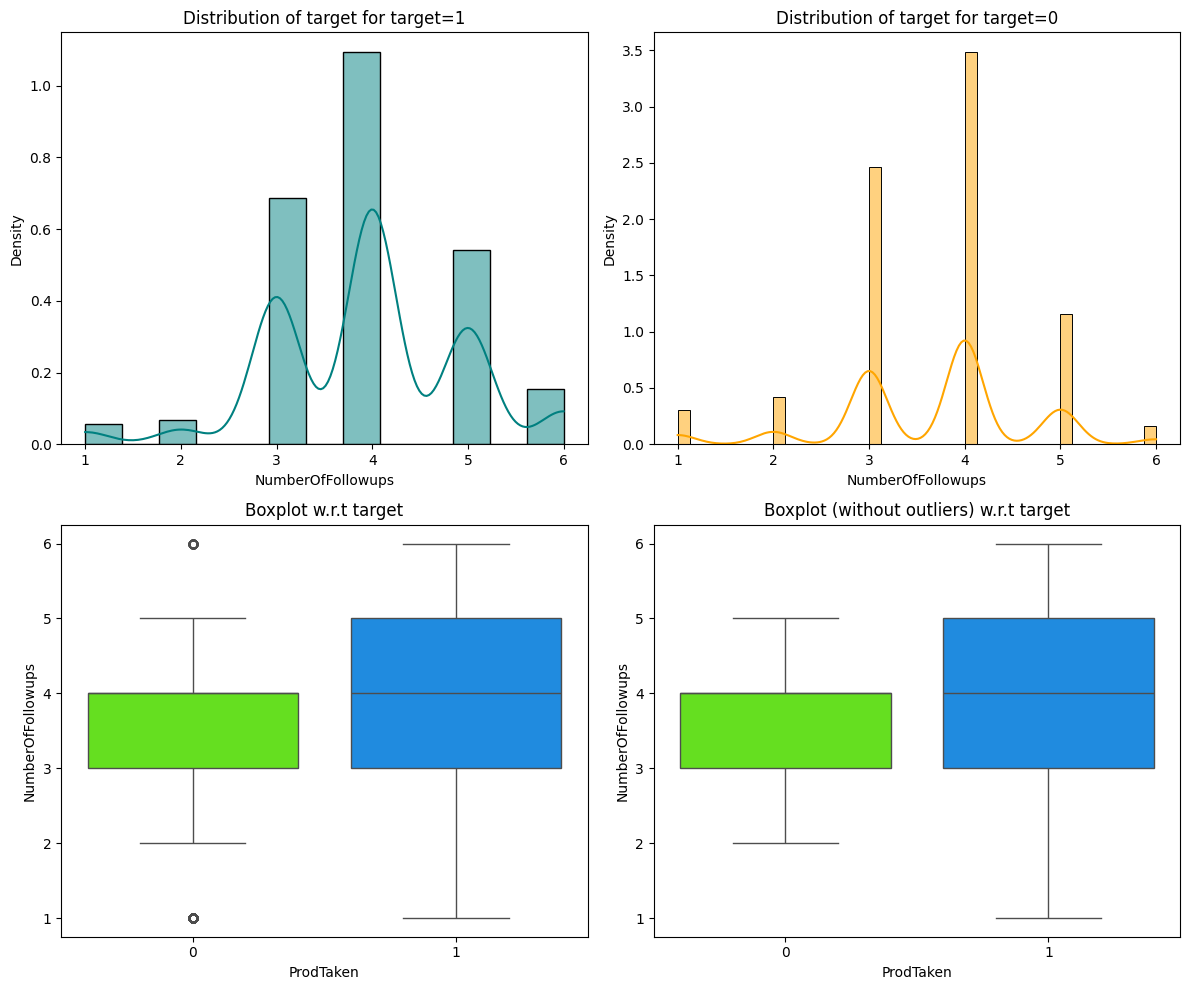

In [125]:
distribution_plot_wrt_target(df, 'NumberOfFollowups', 'ProdTaken')

<b>Observation:</b> There appears to be a slightly larger accumulation of 5s and 6s in the group who took the vacation package, when compared to those who didn't.

#### ProdTaken x NumberOfTrips

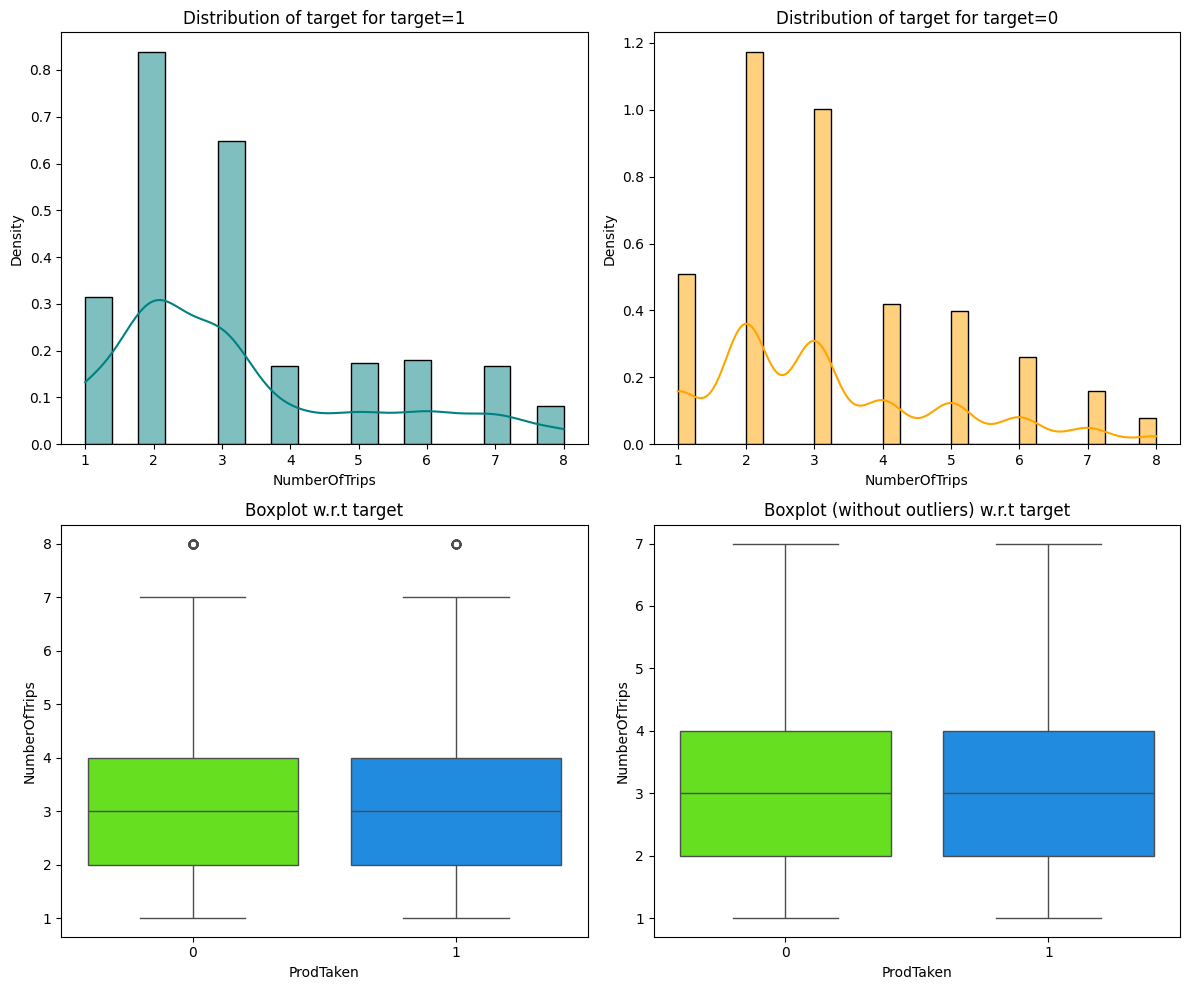

In [126]:
distribution_plot_wrt_target(df, 'NumberOfTrips', 'ProdTaken')

<b>Observation:</b> There is a slightly higher accumulation of entries where the NumberOfTrips value was 4 or 5 in the group who did not take the package, whe compared to those that did.

#### ProdTaken x NumberOfChildrenVisiting

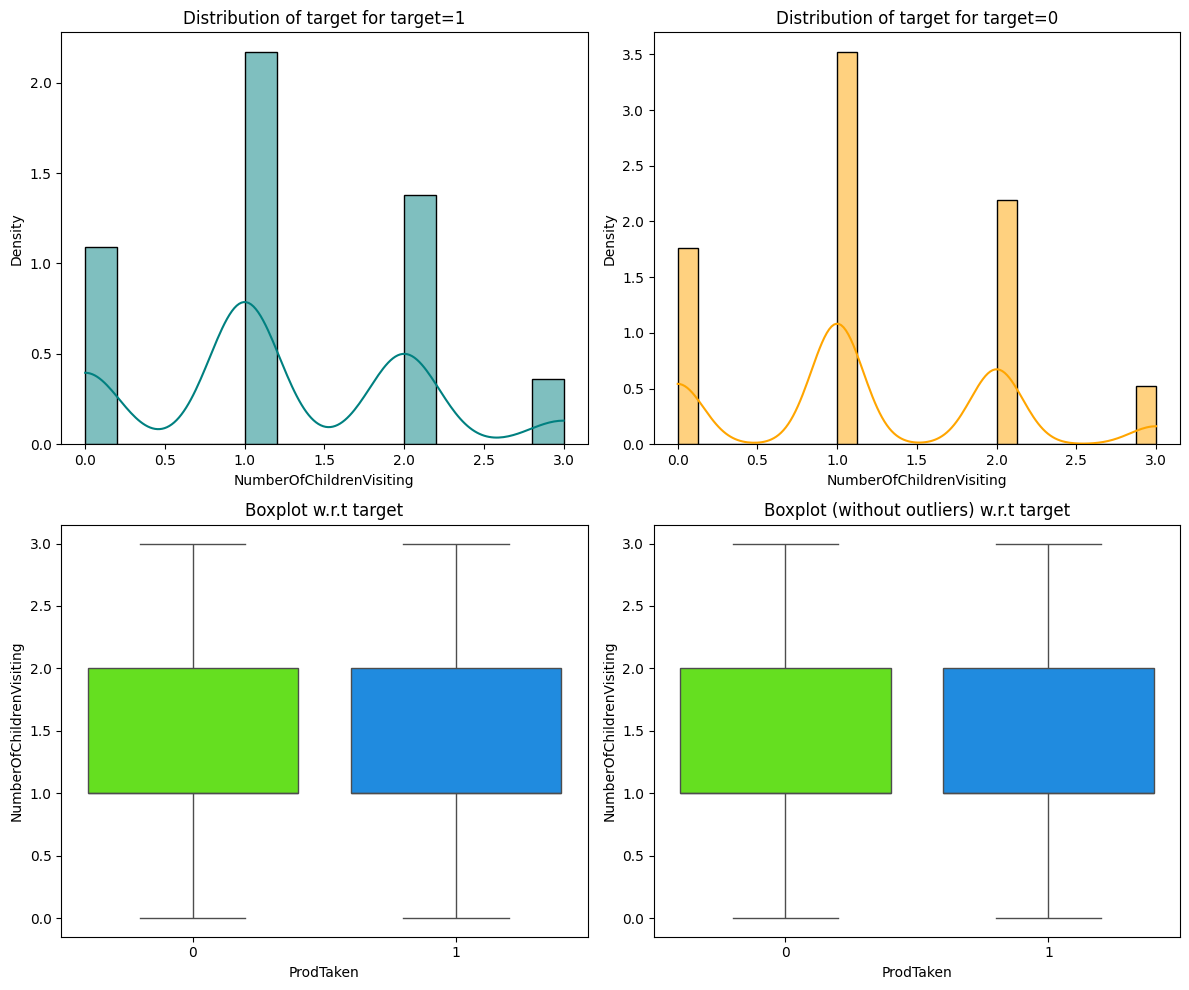

In [127]:
distribution_plot_wrt_target(df, 'NumberOfChildrenVisiting', 'ProdTaken')

<b>Observation:</b> There is not a considerable difference between the distributions of the two sides. This is unsurprising, given the strong relationship with NumberOfPersonVisiting.

#### ProdTaken x MonthlyIncome

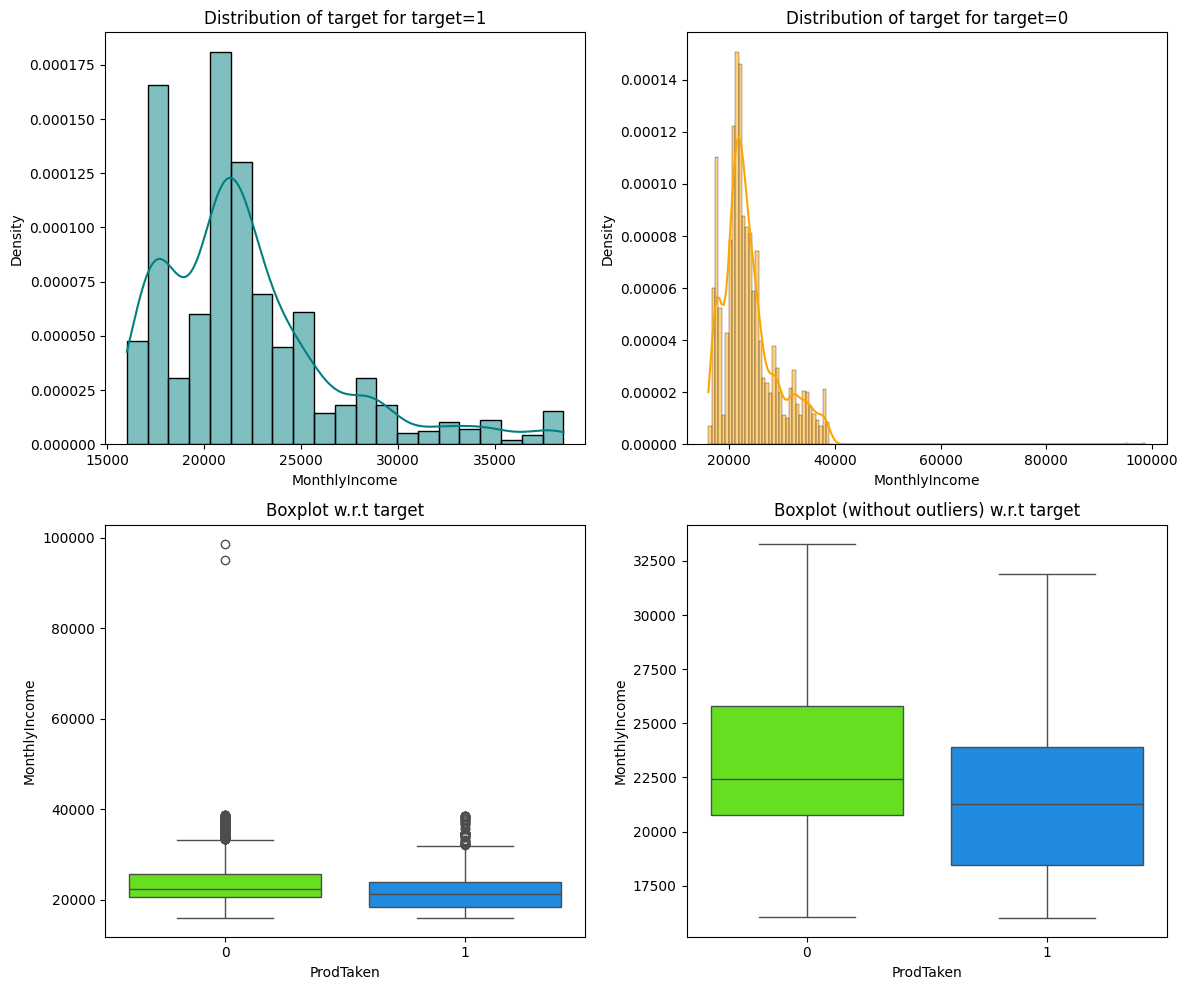

In [128]:
distribution_plot_wrt_target(df, 'MonthlyIncome', 'ProdTaken')

<b>Observation:</b> Surprisingly, there does not appear to be a considerable difference between the distributions of the two sides.

#### ProdTaken x PreferredPropertyStar

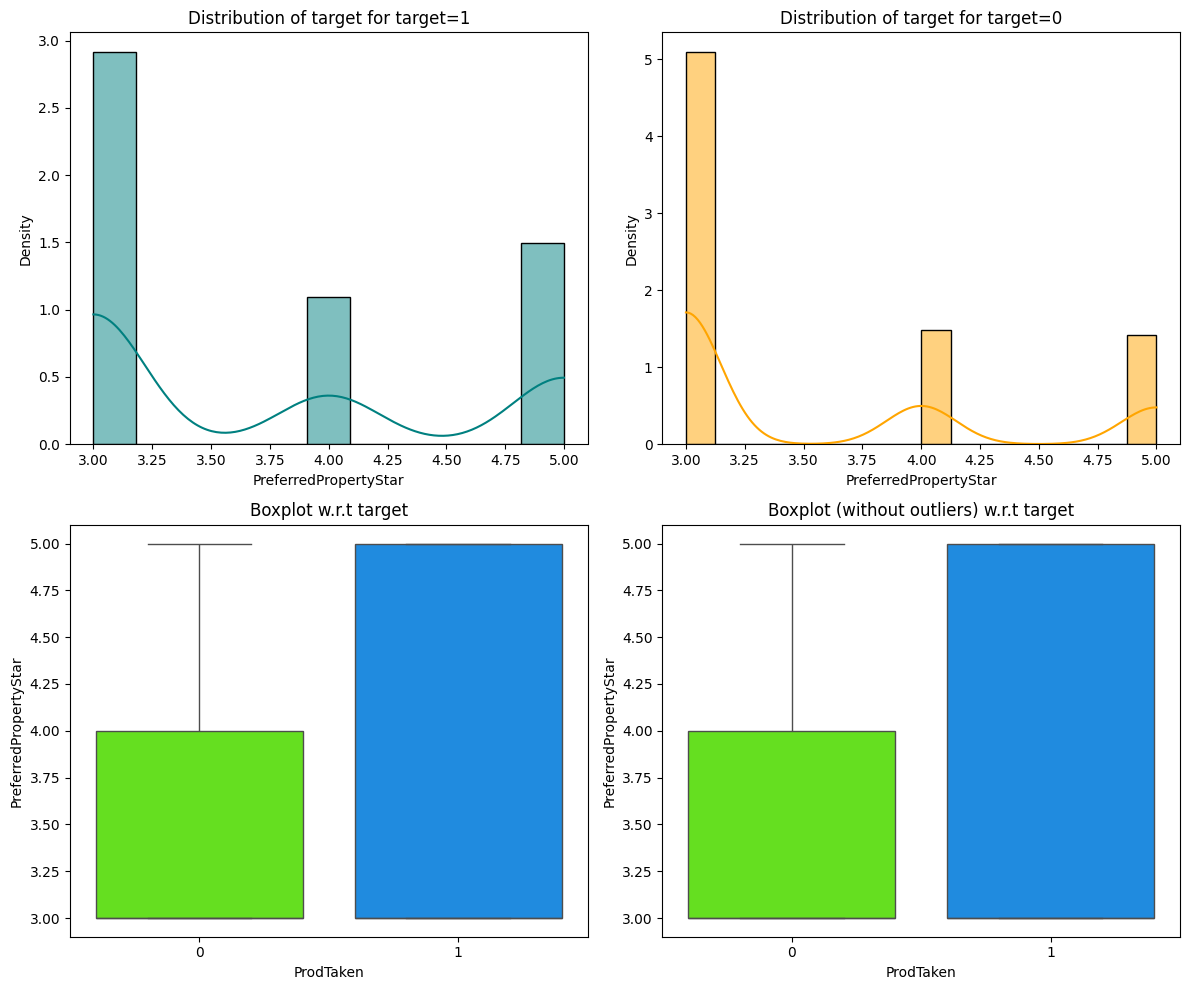

In [129]:
distribution_plot_wrt_target(df, 'PreferredPropertyStar', 'ProdTaken')

<b>Observation:</b> There is a larger accumulation of entries with PreferredPropertyStar values of 5 in the group that took the package, when compared to those that did not.

### EDA Conclusion

- People with passports are more likely to take the package
- Executives have higher percentage to take product
- People took the basic package at a higher percentage
- 50 percent of people are married
- Most frequent satisfaction score is a 3 on the pitch
- Highest correlated features are number of children and number of people visiting
- Longer pitches lead to a slightly higher chance of the package being taken
- Not many areas to gain insight

## Feature Engineering

### Dropping off Duplicated Features

In [130]:
df.head(5)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


Dropping Occupation, since it is highly similar to Designation, and has no real correlation to the target variable.

In [131]:
df = df.drop(labels='Occupation',axis=1)

Unsurprisingly, NumberOfChildrenVisiting has a very strong correlation to NumberOfPersonVisiting, so it isn't necessary to have both of the columns.

In [132]:
df = df.drop(labels='NumberOfChildrenVisiting',axis=1)

### Normalization/Encoding

In [133]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ProdTaken,4863.0,0.188567,0.391204,0.0,0.0,0.0,0.0,1.0
Age,4863.0,37.585647,9.104766,18.0,31.0,36.0,43.0,61.0
CityTier,4863.0,1.654329,0.916498,1.0,1.0,1.0,3.0,3.0
DurationOfPitch,4863.0,15.328398,8.025317,5.0,9.0,13.0,19.0,36.0
NumberOfPersonVisiting,4863.0,2.908081,0.724762,1.0,2.0,3.0,3.0,5.0
NumberOfFollowups,4863.0,3.713346,0.996539,1.0,3.0,4.0,4.0,6.0
PreferredPropertyStar,4863.0,3.578655,0.796907,3.0,3.0,3.0,4.0,5.0
NumberOfTrips,4863.0,3.216944,1.753654,1.0,2.0,3.0,4.0,8.0
Passport,4863.0,0.292412,0.454917,0.0,0.0,0.0,1.0,1.0
PitchSatisfactionScore,4863.0,3.079581,1.366446,1.0,2.0,3.0,4.0,5.0


#### Age

Age, as well as most of the other numerical columns, will be normalized using the MinMaxScaler. 

In [134]:
# Normalizing Age
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['Age']])
df[['Age']] = scaler.transform(df[['Age']])

#### CityTier

There are only three values for CityTier, which effectively makes it a categorical column. As such, its values were encoded using get_dummies.

In [135]:
# Using get_dummies to encode CityTier
df = pd.get_dummies(df, columns=['CityTier'], drop_first=True)

#### DurationOfPitch

In [136]:
# Normalizing DurationOfPitch
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['DurationOfPitch']])
df[['DurationOfPitch']] = scaler.transform(df[['DurationOfPitch']])

#### NumberOfPersonVisiting

In [137]:
# Normalizing NumberOfPersonVisiting
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['NumberOfPersonVisiting']])
df[['NumberOfPersonVisiting']] = scaler.transform(df[['NumberOfPersonVisiting']])

#### NumberOfFollowups

In [138]:
# Normalizing NumberOfFollowups
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['NumberOfFollowups']])
df[['NumberOfFollowups']] = scaler.transform(df[['NumberOfFollowups']])

#### PreferredPropertyStar

While there are, in theory, five values for PreferredPropertyStar, there are only three that are ever used, which makes it a good fit for get_dummies.

In [139]:
# Encoding PreferredPropertyStar
df = pd.get_dummies(df, columns=['PreferredPropertyStar'], drop_first=True)

#### NumberOfTrips

In [140]:
# Normalizing NumberOfTrips
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['NumberOfTrips']])
df[['NumberOfTrips']] = scaler.transform(df[['NumberOfTrips']])

#### PitchSatisfactionScore

In [141]:
# Normalizing PitchSatisfactionScore
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['PitchSatisfactionScore']])
df[['PitchSatisfactionScore']] = scaler.transform(df[['PitchSatisfactionScore']])

#### MonthlyIncome

In [142]:
# Normalizing MonthlyIncome
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['MonthlyIncome']])
df[['MonthlyIncome']] = scaler.transform(df[['MonthlyIncome']])

In [143]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ProdTaken,4863.0,0.188567,0.391204,0.0,0.000000,0.000000,0.000000,1.0
Age,4863.0,0.455480,0.211739,0.0,0.302326,0.418605,0.581395,1.0
DurationOfPitch,4863.0,0.333174,0.258881,0.0,0.129032,0.258065,0.451613,1.0
NumberOfPersonVisiting,4863.0,0.477020,0.181191,0.0,0.250000,0.500000,0.500000,1.0
NumberOfFollowups,4863.0,0.542669,0.199308,0.0,0.400000,0.600000,0.600000,1.0
NumberOfTrips,4863.0,0.316706,0.250522,0.0,0.142857,0.285714,0.428571,1.0
Passport,4863.0,0.292412,0.454917,0.0,0.000000,0.000000,1.000000,1.0
PitchSatisfactionScore,4863.0,0.519895,0.341611,0.0,0.250000,0.500000,0.750000,1.0
OwnCar,4863.0,0.620605,0.485286,0.0,0.000000,1.000000,1.000000,1.0
MonthlyIncome,4863.0,0.091503,0.063552,0.0,0.054119,0.076667,0.114172,1.0


#### TypeofContact

In [144]:
# Encoding TypeofContact
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['TypeofContact'] = label_encoder.fit_transform(df['TypeofContact'])

#### Gender

In [145]:
# Encoding Gender
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])

#### Designation

In [146]:
# Encoding Designation
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Designation'] = label_encoder.fit_transform(df['Designation'])

#### MaritalStatus

In [147]:
# Encoding MaritalStatus
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['MaritalStatus'] = label_encoder.fit_transform(df['MaritalStatus'])

#### ProductPitched

In [148]:
# Encoding ProductPitched
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['ProductPitched'] = label_encoder.fit_transform(df['ProductPitched'])

In [149]:
# Verifying
df.head(10)

,ProdTaken,Age,TypeofContact,DurationOfPitch,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,CityTier_2,CityTier_3,PreferredPropertyStar_4.0,PreferredPropertyStar_5.0
0,1,0.534884,1,0.032258,0,0.50,0.4,1,2,0.000000,1,0.25,1,2,0.060289,False,True,False,False
1,0,0.720930,0,0.290323,1,0.50,0.6,1,0,0.142857,0,0.50,1,2,0.049849,False,False,True,False
2,1,0.441860,1,0.096774,1,0.50,0.6,0,2,0.857143,1,0.50,0,1,0.013076,False,False,False,False
3,0,0.348837,0,0.129032,0,0.25,0.4,0,0,0.142857,1,1.00,1,1,0.022983,False,False,False,False
4,0,0.418605,1,0.096774,1,0.25,0.4,0,0,0.000000,0,1.00,1,1,0.029745,False,False,True,False
5,0,0.325581,0,0.096774,1,0.50,0.4,0,2,0.000000,0,1.00,1,1,0.024907,False,False,False,False
6,0,0.953488,1,0.129032,0,0.25,0.2,0,0,0.571429,1,0.25,1,1,0.020092,False,False,False,True
7,0,0.279070,1,0.806452,1,0.50,0.4,0,1,0.142857,0,0.25,0,1,0.020370,False,False,False,False
8,0,0.465116,0,0.774194,1,0.25,0.6,3,3,0.000000,0,0.50,0,3,0.103025,False,False,False,False
9,0,0.418605,1,0.903226,1,0.50,0.4,1,0,0.857143,0,0.50,1,2,0.051144,False,False,False,False


### Feature Engineering  Final Thoughts

- We considered binning monthly income, to get a clearer idea of target variable correlation between each income bracket. However, the overall correlation between this column and the target variable wasn't strong, so it didn't seem entirely necessary. We could still possibly see how it works after running the model.
- We also thought about changing marital status to just Married or Unmarried but saw some odd differences between divorced entries and single/unmarried entries, so the feature was left alone.
- Used min-max normalization throughout, as none of the distributions for numerical columns are fully gausian, making them a bad fit for standardization. Logarithmic could be used, but did not seem entirely necessary.
- Took out NumberOfChildrenVisiting, with there already being NumberOfPersonVisiting, which had a very strong correlation.
- Took out Occupation, as that and Designation are highly similar.
- Used get_dummies on CityTier and PreferredPropertyStar as there were only 3 unique variables for each column.